# Detección de Spam
En este proyecto crearemos un modelo de Naive Bayes que nos permita predecir si un mensaje de texto es spam o no. Para esto, también haremos uso de la técnica TF-IDF, que nos permite obtener una puntuación para cada palabra de cada mensaje de acuerdo con su frecuencia tanto en el documento como en el corpus.

En este proyecto realizaremos actividades de exploración de datos y preprocesamiento, donde ajustaremos los datos aplicando técnicas de normalización. También aplicaremos la técnica TF-IDF para transformar los mensajes en arreglos de números; posteriormente, crearemos un modelo Naive Bayes y lo evaluaremos a través del uso de métricas de bondad de ajuste que nos permitan comprender cuál es el desempeño del modelo.

# 1. Problema a Resolver
Necesitamos extraer las características principales del conjunto de datos de mensajes de texto que nos permitan, a través de la creación de un modelo, realizar predicciones acerca de si un mensaje de texto es spam o no (ham).

# 2. Librerías
A continuación se presentan las librerías que vamos a utilizar para el desarrollo del proyecto.

In [1]:
# Obtencion del Conjunto de datos (Hugging Face)
from datasets import load_dataset

# Procesamiento de datos
import numpy as np
import pandas as pd

# Manipulacion de Strings
import string

# Generación de gráficos
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Exploracion y preprocesamiento de Textos
import re
from urlextract import URLExtract
from collections import Counter
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

# Division de datos
from sklearn.model_selection import train_test_split

# Modelo de Machine Learning
from sklearn.naive_bayes import ComplementNB

# Ajuste Modelo
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from nltk.tokenize import word_tokenize

# Metricas de Evaluacion del modelo
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import fbeta_score, make_scorer, f1_score

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# 3. Ingesta de Datos
Vamos a comenzar con la ingesta de datos. Para realizar este proyecto haremos uso de un conjunto de datos disponible en la plataforma de Hugging Face. El conjunto de datos es una colección de mensajes de texto en inglés; los mensajes son reales, no sintéticos y no han sido codificados, solamente han sido etiquetados según sean legítimos o spam.

El conjunto de datos que hemos utilizado está disponible en el siguiente enlace:

https://huggingface.co/datasets/ucirvine/sms_spam

Utilizaremos la única división disponible en el conjunto de datos, que es "train", por medio de la siguiente instrucción:

In [2]:
dataset = load_dataset("ucirvine/sms_spam", split="train")

Convertimos el conjunto de datos a un DataFrame de Pandas con la finalidad de que podamos explorarlo y manipularlo más fácilmente.

In [3]:
df = dataset.to_pandas()
df.head()

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


# 4. Análisis Exploratorio de Datos
Durante esta fase, obtendremos las características principales del conjunto de datos. Asimismo, exploraremos si hay presencia de valores nulos o duplicados que puedan afectar el análisis de datos y la posterior creación del modelo.

## 4.1 Resumen de Datos
Comenzaremos obteniendo un resumen del conjunto de datos, de tal forma que nos permita identificar fácilmente el tamaño del conjunto de datos, el tipo de dato que contiene cada columna y comprobar si hay presencia de valores nulos en alguna de las columnas.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sms     5574 non-null   str  
 1   label   5574 non-null   int64
dtypes: int64(1), str(1)
memory usage: 531.4 KB


Del resumen inicial de datos podemos obtener la siguiente información relevante:

1. El conjunto de datos está compuesto por 5574 filas y 2 columnas.
2. Ninguna de las columnas tiene datos nulos, puesto que cada columna tiene 5574 valores no nulos.
3. La columna "sms" contiene el tipo de dato "str", es decir, cadenas de caracteres. Por otro lado, la columna "label" contiene el tipo de dato "int64"; esto nos indica inicialmente que esta columna ya se encuentra en valores numéricos, con lo cual no será necesario realizar una codificación previa a la generación del modelo. Donde 0 corresponde a mensajes válidos y el valor de 1 corresponde a mensaje spam.

## 4.2 Valores Duplicados
Ahora vamos a comprobar si hay presencia de valores duplicados. La posible presencia de valores duplicados puede afectar el análisis, ya que pueden haber observaciones que se encuentran sobrerepresentadas, sesgando el análisis y el modelo que podamos generar en base a ese análisis.

In [5]:
print(df['sms'].duplicated().sum())

403


Vemos que hay 403 valores duplicados; vamos a explorar a qué categoría pertenecen esos registros duplicados del conjunto de datos.

In [6]:
duplicados = df[df['sms'].duplicated()]
duplicados['label'].value_counts()

label
0    309
1     94
Name: count, dtype: int64

Aquí hay algo interesante que podemos notar, y es que la intuición nos podría decir que los mensajes que más se deberían repetir deberían ser de la categoría spam, ¿no? Puesto que uno podría pensar que los mensajes de spam se envían masivamente y, por ende, deberían ser los que más se repiten. Sin embargo, aquí podemos ver que se rompe esa intuición, ya que hay 309 mensajes que se repiten y han sido etiquetados como válidos (ham) y 94 mensajes han sido catalogados como spam, es decir, alrededor del 25% de los mensajes duplicados.

Vamos a explorar un poco más estos datos duplicados con el objetivo de poder comprender las razones por las cuales se puede presentar este fenómeno. Entonces, vamos a agrupar los mensajes duplicados y ordenarlos de forma que se muestren primero los mensajes que más se repiten; además, vamos a obtener los 10 mensajes que más se repiten.

In [7]:
duplicados.groupby('sms').size().reset_index(name='count').sort_values(by='count', ascending=False).head(10)

,sms,count
202,"Sorry, I'll call later\n",29
101,I cant pick the phone right now. Pls send a me...,11
169,Ok...\n,9
171,Okie\n,3
249,"Wen ur lovable bcums angry wid u, dnt take it ...",3
168,Ok.\n,3
161,Ok\n,3
274,Your opinion about me? 1. Over 2. Jada 3. Kusr...,3
4,7 wonders in My WORLD 7th You 6th Ur style 5th...,3
176,Please call our customer service representativ...,3


Aquí ya podemos empezar a hallar la razón por la cual estos mensajes en su mayoría son catalogados como válidos; esto se debe a que son mensajes muy utilizados y que empleamos para comunicarnos de forma cotidiana. Un ejemplo es el mensaje que más se repite, "Sorry, I'll call later", el cual aparece 29 veces; este es un mensaje rápido e informal, probablemente automatizado, que podemos enviar en caso de no poder contestar una llamada en un momento determinado. También podemos ver algunas variaciones de "ok" que son muy utilizadas. Entonces, es por esta razón principal que hay tantos mensajes válidos duplicados: no es solo que una persona haya enviado el mismo mensaje muchas veces, sino que muchas personas distintas escribieron la misma respuesta corta y común.

Una vez identificados los mensajes duplicados y exploradas las características de estos, vamos a proceder a eliminarlos, esto con la finalidad de que el modelo no se vea sesgado por las numerosas apariciones del mismo mensaje de texto, lo cual disminuiría su rendimiento general y su capacidad de generalización.

In [8]:
df.drop_duplicates(subset='sms', inplace=True)

Comprobamos que se hayan eliminado correctamente los valores duplicados y comprobamos el nuevo tamaño que tendrá el conjunto de datos.

In [9]:
print(f'Cantidad duplicados en el dataset: {df["sms"].duplicated().sum()}')
print(f'Cantidad de filas en el dataset: {len(df)}')

Cantidad duplicados en el dataset: 0
Cantidad de filas en el dataset: 5171


## 4.3 Análisis Univariado
Vamos a comenzar con el análisis univariado, donde exploraremos cómo están distribuidos los datos, examinaremos sus estadísticos descriptivos y podremos detectar patrones y tendencias presentes en las características de forma individual. En este caso, dado que contamos solamente con dos variables, una que contiene el mensaje de texto y la otra el valor correspondiente a la etiqueta de mensaje válido o mensaje de spam, examinaremos solamente la columna de la etiqueta del mensaje, de tal forma que guiaremos este análisis univariado respondiendo la siguiente pregunta que nos podemos plantear en relación a esa columna.

### 4.3.1 ¿Cual es la proporción de mensajes que pertenece a la etiqueta de mensaje valido (0) y  cual a mensaje de Spam (1)?

In [10]:
df['label'].value_counts()

label
0    4518
1     653
Name: count, dtype: int64

La gran mayoría de mensajes poseen la etiqueta de mensajes válidos con 4518, mientras que 653 tienen la etiqueta de mensajes inválidos; esto debemos tenerlo en cuenta en la creación del modelo Naive Bayes, ya que el modelo puede ser sesgado gracias a la predominancia de mensajes válidos frente a mensajes inválidos. Vamos a comprobar la proporción de cada etiqueta:

In [11]:
proporcion_clases = df['label'].value_counts(normalize=True) * 100
print(proporcion_clases)

label
0    87.371882
1    12.628118
Name: proportion, dtype: float64


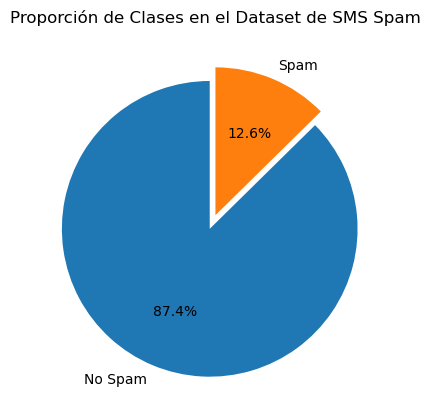

In [12]:
#| label: grafico-proporcion-clases
labels = proporcion_clases.index.map({0: 'No Spam', 1: 'Spam'})

plt.pie(proporcion_clases, labels=labels, autopct='%1.1f%%', startangle=90, explode=(0.1, 0))
plt.title('Proporción de Clases en el Dataset de SMS Spam')
plt.show()

Podemos comprobar que, efectivamente, la gran mayoría de los mensajes no son considerados spam, con cerca del 87%, mientras que los que sí se consideran spam representan alrededor del 12% de la totalidad de los datos.

## 4.4 Análisis Bivariado
Ahora realizaremos el análisis bivariado; para llevarlo a cabo, analizaremos las dos características juntas, de tal forma que podamos extraer características, patrones y tendencias que no puedan ser vistas al analizar una característica de forma individual. Vamos a guiar este análisis bivariado con algunas preguntas que han surgido y que pueden ser respondidas a través de este.

Aquí debemos tener en cuenta que crearemos una copia del conjunto de datos que vamos a poder modificar libremente, con el objetivo de dar respuesta a cada una de las preguntas de la forma más clara y completa posible.

In [13]:
df_analisis = df.copy()

### 4.4.1 ¿Tiene que ver la longitud del mensaje con su etiqueta (spam vs. ham)?
Para responder esta pregunta inicial, vamos a eliminar los signos de puntuación con la finalidad de poder separar claramente cada palabra de cada mensaje; esto lo haremos por medio de una función que se aplicará sobre cada fila del conjunto de datos. Posteriormente, contaremos el número de palabras en cada mensaje y realizaremos un análisis para responder la pregunta.

In [14]:
def eliminar_puntuacion(texto):
    
    translator = str.maketrans('', '', string.punctuation)
    texto_sin_puntuacion = texto.translate(translator)
    
    return texto_sin_puntuacion

Aplicamos la eliminación de la puntuación a las filas del conjunto de datos.

In [15]:
df_analisis['sms'] = df_analisis['sms'].apply(eliminar_puntuacion)
df_analisis.head()

,sms,label
0,Go until jurong point crazy Available only in ...,0
1,Ok lar Joking wif u oni\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor U c already then say\n,0
4,Nah I dont think he goes to usf he lives aroun...,0


También eliminamos la cadena de caracteres "\n", ya que representa un salto de línea; sin embargo, es irrelevante para el análisis.

In [16]:
df_analisis['sms'] = df_analisis['sms'].replace('\n', ' ', regex=True)
df_analisis.head()

,sms,label
0,Go until jurong point crazy Available only in ...,0
1,Ok lar Joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor U c already then say,0
4,Nah I dont think he goes to usf he lives aroun...,0


Ahora separamos cada palabra de cada mensaje de tal forma que cada fila tendrá un arreglo de cadenas de caracteres que componen cada mensaje.

In [17]:
df_analisis['sms'] = df_analisis['sms'].str.split()
df_analisis.head()

,sms,label
0,"[Go, until, jurong, point, crazy, Available, o...",0
1,"[Ok, lar, Joking, wif, u, oni]",0
2,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",1
3,"[U, dun, say, so, early, hor, U, c, already, t...",0
4,"[Nah, I, dont, think, he, goes, to, usf, he, l...",0


Una vez hemos separado cada palabra del mensaje, vamos a contar la cantidad de palabras para cada mensaje. Lo aplicaremos en cada fila.

In [18]:
df_analisis['longitud_sms'] = df_analisis['sms'].apply(len)
df_analisis.head()

,sms,label,longitud_sms
0,"[Go, until, jurong, point, crazy, Available, o...",0,20
1,"[Ok, lar, Joking, wif, u, oni]",0,6
2,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",1,28
3,"[U, dun, say, so, early, hor, U, c, already, t...",0,11
4,"[Nah, I, dont, think, he, goes, to, usf, he, l...",0,13


Ahora, para responder la pregunta planteada, vamos a crear un histograma que presente la longitud de cada mensaje, segmentado en mensajes válidos y mensajes que fueron etiquetados como spam.

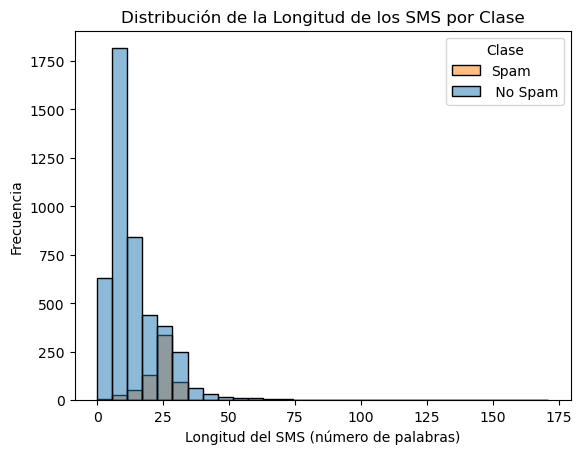

In [19]:
#| label: grafico-longitud-sms

sns.histplot(data=df_analisis, x='longitud_sms', hue='label', bins=30)
plt.title('Distribución de la Longitud de los SMS por Clase')
plt.xlabel('Longitud del SMS (número de palabras)')
plt.ylabel('Frecuencia')
plt.legend(title='Clase', labels=['Spam', ' No Spam'])
plt.show()

De este histograma podemos extraer información valiosa, como la siguiente:

- Independientemente de la etiqueta, la mayor concentración de mensajes tiene una longitud en el rango de 1 a 50 palabras.
- Los mensajes válidos tienden a poseer una menor cantidad de palabras, lo que nos indica que suelen ser más directos, ya que su mayor concentración se posiciona en torno a las 10 palabras.
- En cuanto a los mensajes spam, la mayor concentración de palabras se sitúa en torno a las 20-30 palabras. Esto quiere decir que los mensajes spam suelen tener una longitud ligeramente mayor que los mensajes válidos; sin embargo, sigue existiendo una gran cantidad de mensajes válidos que también se sitúan en torno a las 25 palabras.

Entonces, para responder la pregunta, podemos concluir que, si bien la concentración de palabras de los mensajes spam es ligeramente mayor que la de los mensajes válidos, ambas etiquetas se superponen, lo que nos indica que no hay un umbral o regla clara que podamos establecer para etiquetar los mensajes de acuerdo con su longitud. Esto nos sugiere que es necesario implementar un modelo que nos permita predecir si un mensaje es spam o no, como un modelo de Naive Bayes.

Podemos complementar este análisis mediante la generación de un diagrama de cajas que nos permita identificar con mayor certeza dónde se encuentra la concentración de datos de acuerdo con cada etiqueta:

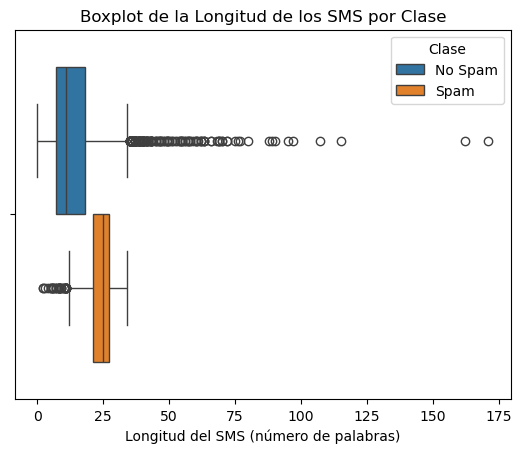

In [20]:
#| label: grafico-cajas-longitud-sms
sns.boxplot(data=df_analisis, x='longitud_sms', hue='label', orient='h')
plt.title('Boxplot de la Longitud de los SMS por Clase')
plt.xlabel('Longitud del SMS (número de palabras)')
plt.legend(title='Clase', labels=['No Spam', 'Spam'])
plt.show()

Aquí podemos confirmar lo siguiente:

- La mayor concentración de datos de los mensajes válidos se encuentra entre 1 y aproximadamente 40 palabras, con una mediana ubicada en torno a las 10.
- En cuanto a los mensajes etiquetados como spam, la mayor concentración de datos se encuentra en mensajes con longitudes de entre 15 y 35 palabras, con una mediana en torno a las 25 palabras.

Ahora, para poder continuar con el análisis, vamos a transformar nuevamente la columna "sms" para que sea una cadena de caracteres y no un arreglo; de tal forma que podamos analizar más fácilmente algunas características importantes de cada mensaje.

In [21]:
df_analisis['sms'] = df_analisis['sms'].apply(lambda palabras: ' '.join(map(str, palabras)))
df_analisis.head()

,sms,label,longitud_sms
0,Go until jurong point crazy Available only in ...,0,20
1,Ok lar Joking wif u oni,0,6
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,28
3,U dun say so early hor U c already then say,0,11
4,Nah I dont think he goes to usf he lives aroun...,0,13


### 4.4.2 ¿Existen patrones de lenguaje, como el uso de mayúsculas, signos especiales o números, que diferencien spam de ham?

#### 4.4.2.1 Mayúsculas
Para responder esta pregunta, vamos a hallar la cantidad de mayúsculas que tiene cada mensaje. Esto lo haremos por medio de una función que aplicaremos a cada fila del conjunto de datos:

In [22]:
def contar_mayusculas(mensaje):
    return sum(1 for char in mensaje if char.isupper())

Aplicamos la función que acabamos de crear al conjunto de datos en una nueva columna.

In [23]:
df_analisis['cantidad_mayusculas'] = df_analisis['sms'].apply(contar_mayusculas)
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas
0,Go until jurong point crazy Available only in ...,0,20,3
1,Ok lar Joking wif u oni,0,6,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,10
3,U dun say so early hor U c already then say,0,11,2
4,Nah I dont think he goes to usf he lives aroun...,0,13,2


Una vez que hemos hallado la cantidad de letras mayúsculas que tiene cada mensaje de nuestro conjunto de datos, al igual que en la pregunta anterior, vamos a crear un histograma que esté segmentado de acuerdo con si un mensaje es válido o es spam:

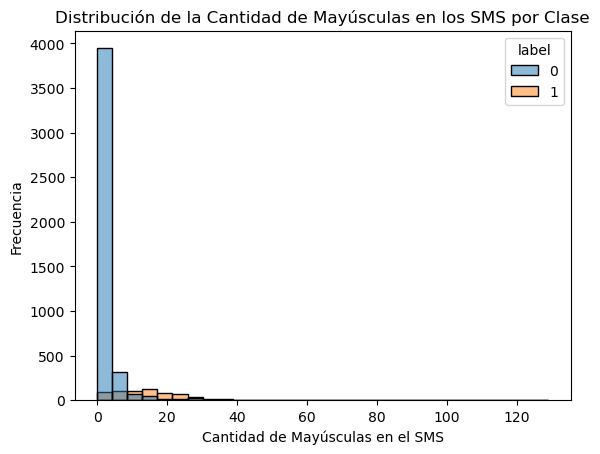

In [24]:
sns.histplot(data=df_analisis, x='cantidad_mayusculas', hue='label', bins=30)
plt.title('Distribución de la Cantidad de Mayúsculas en los SMS por Clase')
plt.xlabel('Cantidad de Mayúsculas en el SMS')
plt.ylabel('Frecuencia')
plt.show()

Encontramos una dificultad al graficar la frecuencia de mayúsculas, ya que, en los mensajes válidos, la gran mayoría tienen muy pocas, lo que no nos permite representar adecuadamente los mensajes de acuerdo con cada etiqueta. Entonces, para solucionar esto, vamos a crear un gráfico de densidad, el cual está representado también mediante barras; sin embargo, el eje Y no representa la frecuencia, sino la densidad, de tal forma que podemos representar mejor cada segmento.

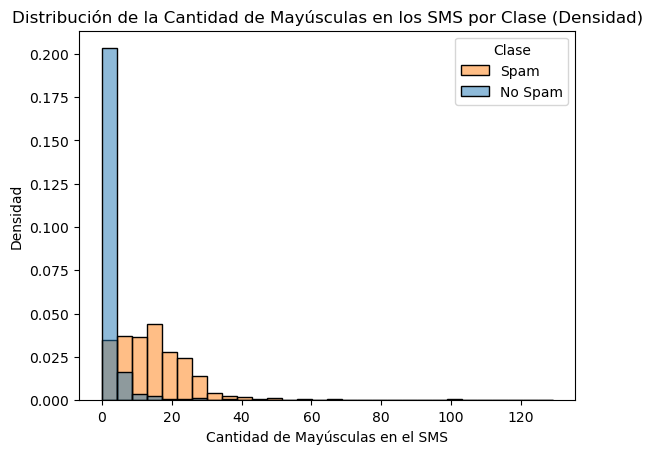

In [25]:
#| label: grafico-cajas-mayusculas-densidad

sns.histplot(data=df_analisis, x='cantidad_mayusculas', hue='label', bins=30, stat='density', common_norm=False)
plt.title('Distribución de la Cantidad de Mayúsculas en los SMS por Clase (Densidad)')
plt.xlabel('Cantidad de Mayúsculas en el SMS')
plt.ylabel('Densidad')
plt.legend(title='Clase', labels=['Spam', 'No Spam'])
plt.show()

Una vez generado el gráfico de densidad, podemos extraer la siguiente información relevante:

- En cuanto a los mensajes válidos: la mayor concentración de datos se encuentra entre 0 y aproximadamente 5 mayúsculas. Esto es comprensible, puesto que, por lo general, las mayúsculas solamente se utilizan al inicio de una frase, en un nombre propio o en siglas, por lo que es esperable que en los mensajes válidos no se utilicen en gran cantidad.
- En los mensajes etiquetados como spam: la mayor concentración de mayúsculas es mucho más amplia, abarcando un rango de aproximadamente 0 a 30. Esto puede explicarse porque los mensajes de spam suelen contener palabras completamente en mayúsculas (como "FREE") para llamar la atención del usuario.

En esta característica que hemos hallado,la cual es la cantidad de mayúsculas utilizadas en los mensajes, hemos obtenido una separación más clara que al utilizar únicamente el número de palabras. Podríamos plantearnos establecer una regla simple, como catalogar automáticamente como spam cualquier mensaje con más de 5 mayúsculas; sin embargo, una regla estática y estricta puede presentar inconvenientes, debido principalmente a las siguientes razones:

- No existe un umbral fijo: los mensajes de ambas categorías se solapan en cuanto al número de mayúsculas. Por ejemplo, hay mensajes con 5 mayúsculas que pueden pertenecer a cualquiera de las dos etiquetas, lo que generaría numerosos falsos positivos. Si una persona escribiera palabras en mayúsculas para expresar emoción, el modelo lo catalogaría erróneamente como spam.
- Vulnerabilidad: esta regla podría ser burlada fácilmente, ya que un emisor de spam podría redactar sus mensajes totalmente en minúsculas para ser clasificado como válido.
- La importancia de la semántica: un mensaje spam se basa en su semántica, no en el uso exclusivo de mayúsculas o minúsculas. Al basarnos solo en esta métrica, dejaríamos de lado uno de los aspectos más importantes para realizar una predicción precisa.

Aquí cabe resaltar que hemos encontrado una característica muy importante, ya que nos permite extraer información sobre cómo se diferencian los mensajes válidos de los de spam. En conclusión, no existe un umbral claro que nos permita etiquetar los mensajes correctamente solo basándonos en el número de mayúsculas; sin embargo, hemos detectado un patrón: los mensajes válidos tienden a utilizar menos mayúsculas que los mensajes spam.

#### 4.4.2.2 Signos Especiales

Ahora vamos a proceder a analizar si hay algún patrón o tendencia en los mensajes de texto que nos permita diferenciar los mensajes válidos de los etiquetados como spam. Para hallar el número de caracteres especiales, comenzaremos definiendo un arreglo que contendrá todos los símbolos que consideramos como tales, por ejemplo, '$', '#', entre otros; de tal forma que estos serán los que se contarán en cada mensaje del conjunto de datos.

In [26]:
caracteres_Especiales = ['$', '%', '!', '@', '#', '&', '*', '?', '/', '\\', '+', '-', '=', '_', '^', '~', '|', '<', '>', ':', ';']

Ahora vamos a definir una función que realice un conteo de los caracteres especiales sobre cada mensaje del conjunto de datos.

In [27]:
def contar_caracteres_especiales(mensaje):
    return sum(1 for char in mensaje if char in caracteres_Especiales)

Aquí debemos tener en cuenta un aspecto muy importante: el conteo de caracteres especiales lo vamos a realizar sobre el conjunto de datos original (es decir, el que no hemos normalizado quitando los signos de puntuación). Asimismo, dicho conteo se asignará a una columna del conjunto de datos de análisis que ya se encuentra normalizado; por lo tanto, lo aplicaremos de la siguiente forma:

In [28]:
df_analisis['cantidad_caracteres_especiales'] = df['sms'].apply(contar_caracteres_especiales)
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales
0,Go until jurong point crazy Available only in ...,0,20,3,0
1,Ok lar Joking wif u oni,0,6,2,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,10,1
3,U dun say so early hor U c already then say,0,11,2,0
4,Nah I dont think he goes to usf he lives aroun...,0,13,2,0


Una vez creada la columna que realiza el conteo de la cantidad de caracteres especiales, vamos a generar una representación gráfica a través de un histograma. Sin embargo, para evitar que la cantidad de mensajes de spam se vea opacada por la de mensajes válidos (ham), el eje Y representará la densidad y el eje X, la cantidad de caracteres especiales.

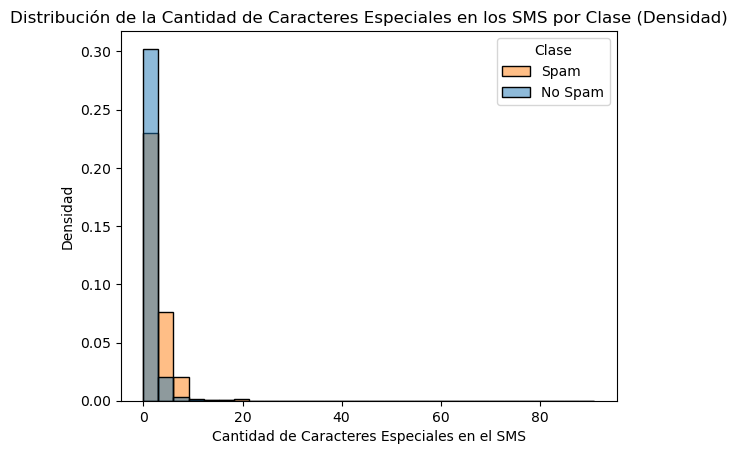

In [29]:
#| label: grafico-cajas-caracteres-especiales-densidad

sns.histplot(data=df_analisis, x='cantidad_caracteres_especiales', hue='label', bins=30, stat='density', common_norm=False)
plt.title('Distribución de la Cantidad de Caracteres Especiales en los SMS por Clase (Densidad)')
plt.xlabel('Cantidad de Caracteres Especiales en el SMS')
plt.ylabel('Densidad')
plt.legend(title='Clase', labels=['Spam', 'No Spam'])
plt.show()

De la representación gráfica podemos extraer la siguiente información:

- Mensajes válidos: la mayor concentración se encuentra en un rango de entre 0 y 5 caracteres especiales.
- Mensajes spam: presentan una concentración un poco más amplia, con un rango aproximado de entre 0 y 10; sin embargo, tienen un comportamiento muy similar al de los mensajes válidos.

De acuerdo con el análisis realizado sobre los caracteres especiales, existe una ligera tendencia: a mayor cantidad de caracteres (a partir de aproximadamente 5), mayor es la probabilidad de que el mensaje sea spam. No obstante, las distribuciones se solapan considerablemente cerca del origen, por lo que no hay un umbral claro que nos permita separar ambas clases de forma limpia. Además, las distribuciones cuentan con una cola larga hacia la derecha (superando en algunos casos los 10 caracteres especiales); por ello, vamos a explorar a qué etiqueta pertenece la mayoría de los mensajes que contienen más de 10 caracteres.

In [30]:
no_spam_mas_10_caracteres_especiales = df_analisis[(df_analisis["cantidad_caracteres_especiales"] > 10) & (df_analisis["label"] == 0)].shape[0]
spam_mas_10_caracteres_especiales = df_analisis[(df_analisis["cantidad_caracteres_especiales"] > 10) & (df_analisis["label"] == 1)].shape[0]
print(f'Número de SMS NO spam con más de 10 caracteres especiales: {no_spam_mas_10_caracteres_especiales}')
print(f'Número de SMS spam con más de 10 caracteres especiales: {spam_mas_10_caracteres_especiales}')

Número de SMS NO spam con más de 10 caracteres especiales: 32
Número de SMS spam con más de 10 caracteres especiales: 6


Cuando exploramos los mensajes con más de 10 caracteres especiales, encontramos que hay una gran mayoría de mensajes válidos respecto a los de spam; es decir, de 38 mensajes que poseen más de 10 caracteres especiales, 32 son válidos y tan solo 6 son spam. Vamos a representar estas proporciones gráficamente con la finalidad de comprender mejor la distribución de los mensajes que pertenecen a cada etiqueta.

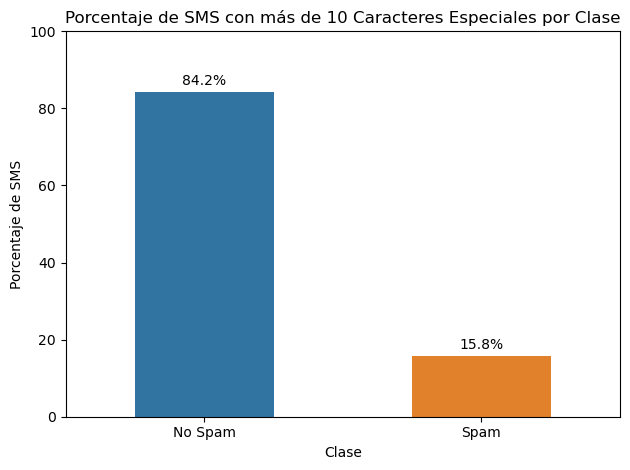

In [31]:
#| label: grafico-barras-caracteres-especiales

total = no_spam_mas_10_caracteres_especiales + spam_mas_10_caracteres_especiales

ax = sns.barplot(
    data=pd.DataFrame({
    'cantidad_caracteres_especiales': [
        no_spam_mas_10_caracteres_especiales / total * 100,
        spam_mas_10_caracteres_especiales / total * 100
    ],
    'label': ['No Spam', 'Spam']
}),
    x='label',
    y='cantidad_caracteres_especiales',
    hue='label',
    dodge=False,
    width=0.5,
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Porcentaje de SMS con más de 10 Caracteres Especiales por Clase')
plt.xlabel('Clase')
plt.ylabel('Porcentaje de SMS')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Del total de 38 mensajes que contienen más de 10 caracteres especiales, el 84.2% son válidos y el 15.8% restante está etiquetado como spam. Esto nos da la impresión de que los mensajes con más de 10 caracteres especiales son más propensos a ser válidos que spam; sin embargo, debemos tener en cuenta las dimensiones originales del conjunto de datos, el cual está compuesto por 5171 filas, de las cuales tan solo 38 superan los 10 caracteres especiales. Es decir, este comportamiento se explica por el desbalance de clases original, dado que la gran mayoría de los mensajes son válidos (ham). Cualquier subgrupo con muy baja representatividad estadística tenderá a replicar esa proporción del conjunto de datos, de tal forma que esta resulta demasiado baja para concluir que existe una tendencia clara. Esto, además, podría ir en contra del patrón principal, el cual establece que a mayor cantidad de caracteres especiales, hay mayor probabilidad de que el mensaje sea etiquetado como spam. Por lo tanto, debemos realizar esta aclaración en la conclusión de la pregunta planteada. Respecto a ella, podemos concluir que sí existe una tendencia hacia el spam a medida que aumenta la cantidad de caracteres especiales, aunque cabe aclarar que, por sí sola, esta característica no es concluyente; asimismo, por encima de 10 caracteres especiales, no hay presencia de suficientes observaciones para extraer un patrón o tendencia definitiva.

#### 4.4.2.3 Números
Para calcular la cantidad de números que posee cada mensaje, vamos a seguir una serie de pasos similar a la que hemos desarrollado en los ítems anteriores; de tal forma que comenzaremos creando la función que cuente los números de cada mensaje:

In [32]:
def contar_numeros(mensaje):
    return sum(1 for char in mensaje if char.isdigit())

Aplicamos la función en el conjunto de datos.

In [33]:
df_analisis['cantidad_numeros'] = df['sms'].apply(contar_numeros)
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros
0,Go until jurong point crazy Available only in ...,0,20,3,0,0
1,Ok lar Joking wif u oni,0,6,2,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,10,1,25
3,U dun say so early hor U c already then say,0,11,2,0,0
4,Nah I dont think he goes to usf he lives aroun...,0,13,2,0,0


Ahora, como ya hemos creado la columna que realiza el conteo de números que contiene cada mensaje del conjunto de datos, vamos a representar gráficamente la distribución de estos, segmentando los mensajes que son válidos (ham) de los que son etiquetados como spam. Lo haremos a través de un histograma que represente la densidad de mensajes de acuerdo con la cantidad de números que contienen:

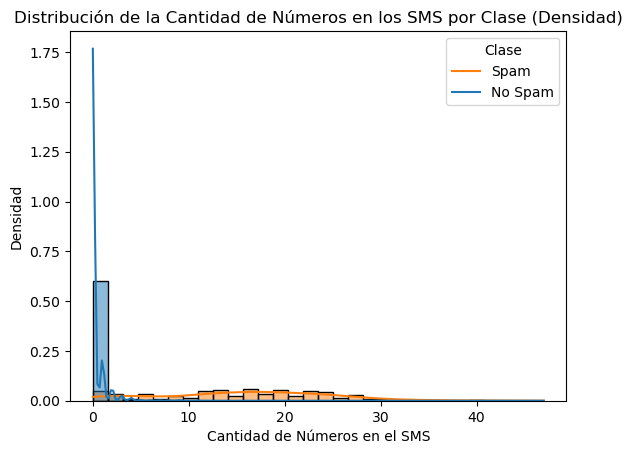

In [34]:
#| label: distribucion-cantidad-numeros-densidad

sns.histplot(data=df_analisis, x='cantidad_numeros', hue='label', bins=30, stat='density',common_norm=False, kde=True)
plt.title('Distribución de la Cantidad de Números en los SMS por Clase (Densidad)')
plt.xlabel('Cantidad de Números en el SMS')
plt.ylabel('Densidad')
plt.legend(title='Clase', labels=['Spam', 'No Spam'])
plt.show()

De la distribución de la cantidad de números en los mensajes podemos ver un patrón claro, del cual extraemos la siguiente información valiosa:

- Mensajes válidos: la gran mayoría contiene muy pocos números (aproximadamente de 1 a 3) o directamente ninguno; es decir, la distribución es asimétrica positiva, con una concentración muy alta en torno al 0.
- Mensajes spam: el rango se amplía considerablemente, ya que presentan mayor dispersión. Existe una concentración de datos en torno a los 10 a 30 números por mensaje. Esto se explica porque, generalmente, los mensajes de spam especifican montos altos para llamar la atención del usuario, indican cuentas para depósitos o incluyen números de teléfono sobre los cuales se espera que el usuario haga clic. Este comportamiento es coherente con el objetivo de este tipo de mensajes.

Aquí sí podemos observar un patrón bastante claro: mientras que los mensajes válidos casi no contienen números, los de spam suelen incluir varios, con una frecuencia muy baja en cantidades pequeñas. Esta característica nos ha brindado información valiosa sobre el comportamiento de los mensajes spam. En respuesta a la pregunta, concluimos que la cantidad de números presenta un patrón que nos permite identificar, con un grado de certeza moderado, si corresponden a un mensaje válido o a uno de spam. Esto se debe a que, a mayor cantidad de números, hay más probabilidad de que el mensaje sea spam; sin embargo, incluso cuando el mensaje no contiene números, existe una pequeña probabilidad de que sea spam. Al ser una regla simple y fácil de evadir, no podemos utilizarla como un criterio estático para etiquetar mensajes; en su lugar, debemos emplear un modelo más complejo que capture también la semántica del texto.

A continuación, crearemos un diagrama de cajas que nos permita comprobar la validez de estas conclusiones obtenidas a través del análisis de la cantidad de números en los mensajes:

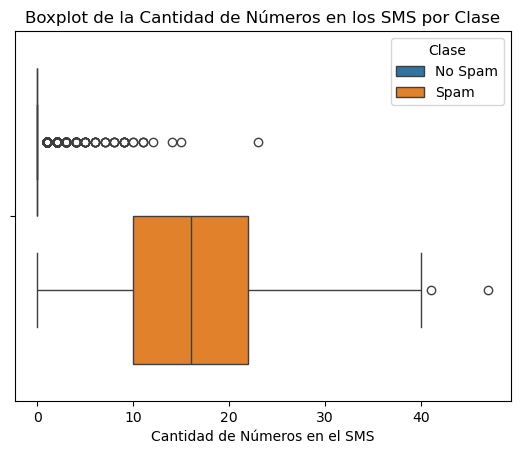

In [35]:
#| label: grafico-cajas-cantidad-numeros-densidad

sns.boxplot(data=df_analisis, x='cantidad_numeros', hue='label', orient='h')
plt.title('Boxplot de la Cantidad de Números en los SMS por Clase')
plt.xlabel('Cantidad de Números en el SMS')
plt.legend(title='Clase', labels=['No Spam', 'Spam'])
plt.show()

Aquí podemos comprobar que, efectivamente, la mayor concentración de datos de mensajes válidos se encuentra en 0 números, mientras que la mayoría de los etiquetados como spam suelen tener una cantidad de números en el rango de 10 a 20, ubicándose la mediana en torno a los 15 números dentro de los mensajes.

### 4.4.3 ¿Los mensajes que contienen URLs son más propensos a ser spam?

Ahora vamos a explorar si existe alguna relación entre los mensajes que contienen alguna URL y los etiquetados como spam. Para esto, utilizaremos la librería `urlextract`, que nos permite determinar con un alto grado de certeza si un mensaje contiene una URL. Cabe aclarar que esto también podríamos lograrlo mediante expresiones regulares detectando patrones como ".com", ".net", "http", entre otros; sin embargo, para obtener el mayor grado de precisión, es recomendable usar esta librería, ya que emplea una lista de dominios de gran volumen provista por la IANA (Internet Assigned Numbers Authority). Esto nos permite detectar URLs sin depender de un patrón estático que podría omitir diversos dominios.

Para llevar a cabo esta comprobación, crearemos una función que determine si un mensaje contiene o no una URL, de tal forma que, en caso de contar con una o más, retorne el valor de 1 y, en caso contrario, retorne 0.

In [36]:
def contiene_url(mensaje):
    extractor = URLExtract()
    return 1 if extractor.has_urls(mensaje) else 0

Vamos a aplicar esta función a cada fila del conjunto de datos. Es importante resaltar que la función debe ejecutarse sobre el conjunto de datos original y no sobre el que ya hemos sometido a tareas de limpieza (como eliminar la puntuación), ya que, de lo contrario, la función no podrá identificar los patrones necesarios para detectar una URL. Los resultados serán almacenados en una nueva columna del conjunto de datos limpio.

In [37]:
df_analisis['contiene_url'] = df['sms'].apply(contiene_url)
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
0,Go until jurong point crazy Available only in ...,0,20,3,0,0,0
1,Ok lar Joking wif u oni,0,6,2,0,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,10,1,25,0
3,U dun say so early hor U c already then say,0,11,2,0,0,0
4,Nah I dont think he goes to usf he lives aroun...,0,13,2,0,0,0


Ahora que hemos aplicado la función en cada una de las filas del conjunto de datos, vamos a comprobar cuántas filas contienen una o más URLs:

In [38]:
df_analisis[df_analisis['contiene_url'] == 1]

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
12,URGENT You have won a 1 week FREE membership i...,1,26,40,5,20,1
15,XXXMobileMovieClub To use your credit click th...,1,19,23,8,0,1
164,PLS STOP bootydelious 32F is inviting you to b...,1,24,31,8,13,1
191,Are you unique enough Find out from 30th Augus...,1,10,3,1,2,1
225,500 New Mobiles from 2004 MUST GO Txt NOKIA to...,1,20,20,7,31,1
...,...,...,...,...,...,...,...
5458,For the most sparkling shopping breaks from 45...,1,16,1,1,13,1
5464,Txt CALL to No 86888 claim your reward of 3 ho...,1,25,11,6,10,1
5468,httptms widelivecomindex wmlid820554ad0a170557...,1,5,3,7,17,1
5477,Dhoni have luck to win some big titleso we wil...,0,11,1,1,0,1


Hay 160 filas que contienen URLs; aunque esta es una porción pequeña del conjunto de datos, nos puede dar información valiosa acerca de la relación entre la presencia de URLs y la etiqueta de spam. Podemos comprobar que la función se haya ejecutado correctamente explorando algún mensaje SMS que contenga una o más URLs.

In [39]:
df['sms'][191]

'Are you unique enough? Find out from 30th August. www.areyouunique.co.uk\n'

La función se ha ejecutado correctamente y ha identificado los mensajes que contienen alguna URL. Vamos a comprobar la proporción de mensajes que tienen URL con respecto al total del conjunto de datos.

In [40]:
df_analisis['contiene_url'].value_counts(normalize=True) * 100

contiene_url
0    96.905821
1     3.094179
Name: proportion, dtype: float64

De todos los mensajes del conjunto de datos, tan solo el 3% contiene URLs, lo cual representa una proporción baja del total; sin embargo, ahora vamos a explorar cómo se etiquetan los mensajes según si poseen URLs o no.

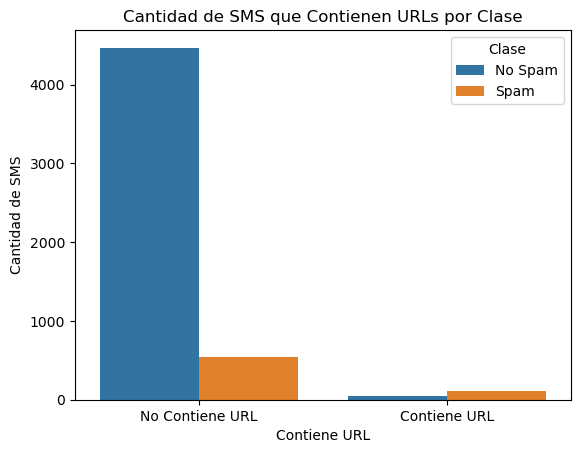

In [41]:
#| label: grafico-cantidad-sms-url

sns.countplot(data=df_analisis, x='contiene_url', hue='label')
plt.title('Cantidad de SMS que Contienen URLs por Clase')
plt.xticks([0, 1], ['No Contiene URL', 'Contiene URL'])
plt.xlabel('Contiene URL')
plt.ylabel('Cantidad de SMS')
plt.legend(title='Clase', labels=['No Spam', 'Spam'])
plt.show()

De esta gráfica ya podemos empezar a extraer información valiosa, como la siguiente:

- Sin URLs: Existe una gran predominancia de mensajes válidos; sin embargo, aún hay una cantidad moderada de mensajes que, pese a no contener URLs, son etiquetados como spam.
- Con URLs: La probabilidad se invierte; es decir, es más probable que el mensaje sea spam a que sea válido, ya que representan una mayor cantidad en esta categoría.

El análisis de este gráfico nos permite validar que la presencia de una URL es un fuerte indicador de que el mensaje es spam; sin embargo, debido al desbalance general del conjunto de datos, el volumen total de spam sin URL supera al de spam con URL. A continuación, crearemos una tabla de contingencia que nos permita identificar cuántos mensajes, tanto con URLs como sin ellas, son etiquetados como válidos (ham) o spam; esto nos dará valores más precisos que los observados en la gráfica.

In [42]:
pd.crosstab(df_analisis['contiene_url'], df_analisis['label'], rownames=['Contiene URL'], colnames=['Clase'])

Clase,0,1
Contiene URL,,
0,4468,543
1,50,110


Existe una gran diferencia en cómo se etiquetan los mensajes dependiendo de si contienen URLs o no. A continuación, presentaremos esta información en proporciones para visualizar más claramente la cantidad que pertenece a cada categoría:

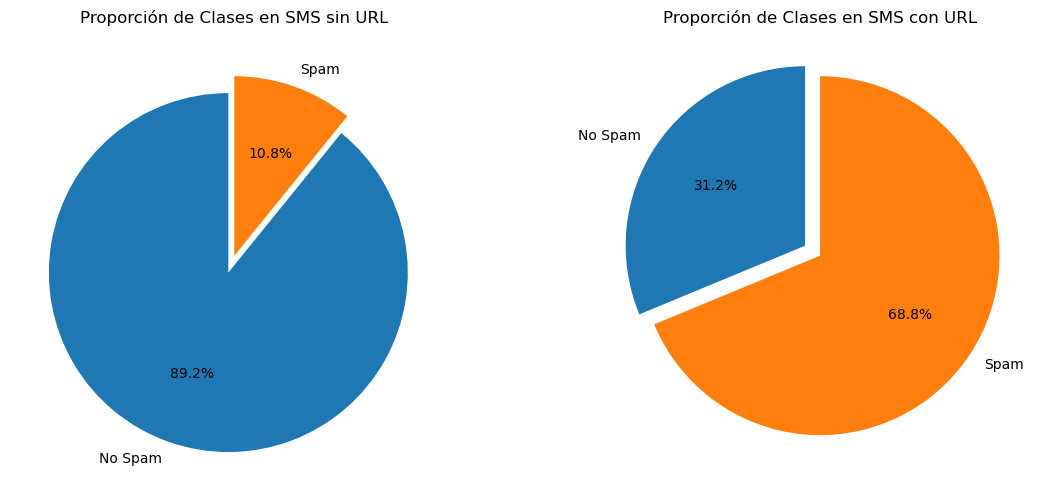

In [43]:
#| label: grafico-proporcion-clases-url

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(df_analisis[df_analisis['contiene_url'] == 0]['label'].value_counts().reindex([0, 1], fill_value=0), labels=['No Spam', 'Spam'], autopct='%1.1f%%', startangle=90, explode=(0.1, 0))
axes[0].set_title('Proporción de Clases en SMS sin URL')
axes[1].pie(df_analisis[df_analisis['contiene_url'] == 1]['label'].value_counts().reindex([0, 1], fill_value=0), labels=['No Spam', 'Spam'], autopct='%1.1f%%', startangle=90, explode=(0.1, 0))
axes[1].set_title('Proporción de Clases en SMS con URL')
plt.tight_layout()
plt.show()

Aquí podemos confirmar el patrón que hemos venido explorando en relación con el comportamiento de los mensajes que contienen o no URLs:

- Mensajes sin URLs: La gran mayoría son considerados válidos, representando el 89.2% del total de esta categoría, mientras que los mensajes de spam se sitúan en torno al 10.8%.
- Mensajes con URLs: El 68.8% son etiquetados como spam, frente al 31.2% que son considerados válidos.

En conclusión, sí existe una relación clara entre la presencia de URLs y la probabilidad de que un mensaje sea spam. Si un mensaje contiene una URL, la probabilidad de que sea spam es del 68.8%, frente a un 31.2% de probabilidad de que sea válido. Esto contrasta con los mensajes que no contienen URLs, donde las probabilidades se invierten: es mucho más probable que sean válidos (89.2%) a que sean spam (10.8%). Este fenómeno se explica por el desbalance general del conjunto de datos, donde predomina la clase de mensajes válidos. Sin embargo, al filtrar por la presencia de URLs, esta tendencia se rompe drásticamente y el spam pasa a ser la mayoría, lo que indica que esta característica posee una alta capacidad predictiva.

### 4.4.4 ¿Cuáles son las palabras más comunes en los mensajes de spam? ¿Y en los de ham?

Para responder esta pregunta, debemos llevar a cabo algunos pasos previos que nos permitan descubrir las palabras clave que diferencian los mensajes válidos (ham) de los etiquetados como spam. Los procedimientos que realizaremos a continuación nos permitirán estandarizar cada una de las palabras presentes en los mensajes de texto:

- **Convertimos todos los Strings del mensaje a minúsculas**

In [44]:
df_analisis['sms'] = df_analisis['sms'].str.lower()
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
0,go until jurong point crazy available only in ...,0,20,3,0,0,0
1,ok lar joking wif u oni,0,6,2,0,0,0
2,free entry in 2 a wkly comp to win fa cup fina...,1,28,10,1,25,0
3,u dun say so early hor u c already then say,0,11,2,0,0,0
4,nah i dont think he goes to usf he lives aroun...,0,13,2,0,0,0


- **Tokenizamos las cadenas de texto**, es decir, separamos cada palabra del SMS, de tal forma que se transforma en un arreglo que contiene cadenas de caracteres.

In [45]:
df_analisis['sms'] = df_analisis['sms'].str.split()
df_analisis.head()

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
0,"[go, until, jurong, point, crazy, available, o...",0,20,3,0,0,0
1,"[ok, lar, joking, wif, u, oni]",0,6,2,0,0,0
2,"[free, entry, in, 2, a, wkly, comp, to, win, f...",1,28,10,1,25,0
3,"[u, dun, say, so, early, hor, u, c, already, t...",0,11,2,0,0,0
4,"[nah, i, dont, think, he, goes, to, usf, he, l...",0,13,2,0,0,0


- **Separamos los mensajes que son válidos y los mensajes de spam**

In [46]:
df_analisis_No_Spam = df_analisis[df_analisis['label'] == 0]
df_analisis_No_Spam

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
0,"[go, until, jurong, point, crazy, available, o...",0,20,3,0,0,0
1,"[ok, lar, joking, wif, u, oni]",0,6,2,0,0,0
3,"[u, dun, say, so, early, hor, u, c, already, t...",0,11,2,0,0,0
4,"[nah, i, dont, think, he, goes, to, usf, he, l...",0,13,2,0,0,0
6,"[even, my, brother, is, not, like, to, speak, ...",0,16,2,0,0,0
...,...,...,...,...,...,...,...
5567,"[huh, y, lei]",0,3,1,0,0,0
5570,"[will, ü, b, going, to, esplanade, fr, home]",0,8,1,1,0,0
5571,"[pity, was, in, mood, for, that, soany, other,...",0,9,2,2,0,0
5572,"[the, guy, did, some, bitching, but, i, acted,...",0,26,2,0,0,0


In [47]:
df_analisis_Spam = df_analisis[df_analisis['label'] == 1]
df_analisis_Spam

,sms,label,longitud_sms,cantidad_mayusculas,cantidad_caracteres_especiales,cantidad_numeros,contiene_url
2,"[free, entry, in, 2, a, wkly, comp, to, win, f...",1,28,10,1,25,0
5,"[freemsg, hey, there, darling, its, been, 3, w...",1,32,7,3,4,0
8,"[winner, as, a, valued, network, customer, you...",1,26,12,3,19,0
9,"[had, your, mobile, 11, months, or, more, u, r...",1,29,14,2,13,0
11,"[six, chances, to, win, cash, from, 100, to, 2...",1,26,17,4,22,0
...,...,...,...,...,...,...,...
5539,"[want, explicit, sex, in, 30, secs, ring, 0207...",1,16,17,3,21,0
5542,"[asked, 3mobile, if, 0870, chatlines, inclu, i...",1,33,104,0,14,0
5549,"[had, your, contract, mobile, 11, mnths, lates...",1,27,20,3,2,0
5568,"[reminder, from, o2, to, get, 250, pounds, fre...",1,28,14,1,5,0


Una vez que hemos separado los mensajes válidos (ham) de los etiquetados como spam, debemos tener en cuenta que los mensajes suelen contener muchas palabras comunes, como conectores o elementos gramaticales que se repiten frecuentemente y no aportan información relevante sobre el objetivo o el tema del mensaje. A estas palabras se les denomina *stopwords*. La librería NLTK cuenta con diversas funciones para realizar el preprocesamiento de cadenas de texto con el fin de identificar sus características principales. Por esta razón, utilizaremos esta librería para obtener las stopwords del idioma inglés de la siguiente forma:

In [48]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/anderson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

La asignamos a un conjunto; allí podemos explorar los elementos por los cuales está conformada la lista de stopwords y la cantidad de elementos que contiene el conjunto.

In [49]:
stop_words = set(nltk.corpus.stopwords.words('english'))
print(stop_words)
print(f'Cantidad de stopwords: {len(stop_words)}')

{'below', 'i', 'shouldn', 'of', 'didn', "should've", 'm', 'they', 'y', 'mustn', 'hasn', 'ourselves', "hasn't", 'over', "they'd", "aren't", "shouldn't", 'theirs', 'until', 'both', "wouldn't", 'after', "hadn't", 'with', 'did', 'which', 'each', 'to', "that'll", 'why', "shan't", "he's", "i'd", 'just', 'ours', 'itself', 'their', "it'd", 'now', 'that', 'where', "weren't", 'own', 'this', 'how', 'while', 'him', "mightn't", 'here', "mustn't", 'his', "they'll", 'above', 'those', 'an', 'too', 'our', "you'll", 'yours', 'd', 'having', 'what', 'isn', 'yourselves', 'does', 'she', 'her', 'shan', 'my', 'such', 'them', 'very', 'because', 'only', "we'll", 'through', "doesn't", "they're", 'has', "couldn't", 'on', 'any', "we'd", 'll', "you'd", "didn't", "we're", 'whom', 'herself', 'some', "wasn't", 'out', "he'll", 'under', 'me', "we've", 'if', 'will', 'you', 'himself', "he'd", "they've", 'further', 's', 'there', 'for', 'between', 'do', 'at', "she'll", 'been', 'or', 'before', 'ma', 'yourself', 're', 'doing'

Contamos con 198 stopwords; sin embargo, existen términos que siguen siendo frecuentes, especialmente en el lenguaje informal propio de los mensajes SMS. Por ello, añadiremos algunos elementos que aparecen constantemente en estos mensajes para excluirlos del conteo, dado que, en este caso particular, no aportan información relevante sobre el objetivo o el tema principal según su etiqueta.

In [50]:
stop_words.update(['u', '2', 'ur', '4', 'dont', 'get', 'go', 'ok', 'lt', 'gt', 'ü', 'im', 'cant', 'wont', 'da', 'r', 'n', 'ive', 'youre', 'he', 'she', 'it', 'we', 'they', 'ill', 'thats'])

Asimismo, previamente eliminamos la puntuación de los mensajes SMS; sin embargo, sucede algo particular con la cadena `&lt;#&gt;`. Esta es una etiqueta de privacidad que indica que el mensaje original contenía un número, código o dato sensible; al eliminar la puntuación, dicha cadena ha quedado como `ltgt`. Por ello, también la añadiremos al conjunto de *stopwords*, ya que no aporta información semántica, sino que es un residuo derivado del proceso de limpieza.

In [51]:
stop_words.update(['ltgt'])

Para realizar el conteo utilizaremos la función `Counter` de la librería `collections`, la cual permite determinar la frecuencia de cada palabra en ambos conjuntos de datos, excluyendo aquellas que formen parte del conjunto de *stopwords*. Esto nos permitirá identificar con claridad qué palabras son las más utilizadas, tanto en los mensajes válidos como en los clasificados como spam.

In [52]:
counter_no_spam = Counter([word for sms in df_analisis_No_Spam['sms'] for word in sms if word not in stop_words])
counter_spam = Counter([word for sms in df_analisis_Spam['sms'] for word in sms if word not in stop_words])

Comenzaremos analizando los mensajes válidos (ham); para ello, exploraremos primero la cantidad total de palabras que conforman el conjunto de datos de dichos mensajes.

In [53]:
counter_no_spam.total()

32858

El conjunto de datos contiene 32,858 palabras, excluyendo las stopwords. A continuación, exploraremos las 20 palabras que se repiten con mayor frecuencia en los mensajes SMS válidos (ham). Para ello, presentaremos un listado de las palabras más comunes, seguido de dos representaciones gráficas que permitirán visualizar su frecuencia con mayor facilidad: un gráfico de barras y una nube de palabras.

In [54]:
counter_no_spam.most_common(20)

[('got', 226),
 ('like', 221),
 ('know', 221),
 ('come', 211),
 ('good', 207),
 ('call', 186),
 ('time', 181),
 ('love', 173),
 ('day', 169),
 ('going', 162),
 ('want', 160),
 ('lor', 157),
 ('one', 156),
 ('need', 153),
 ('home', 151),
 ('still', 142),
 ('see', 134),
 ('think', 126),
 ('back', 126),
 ('well', 125)]

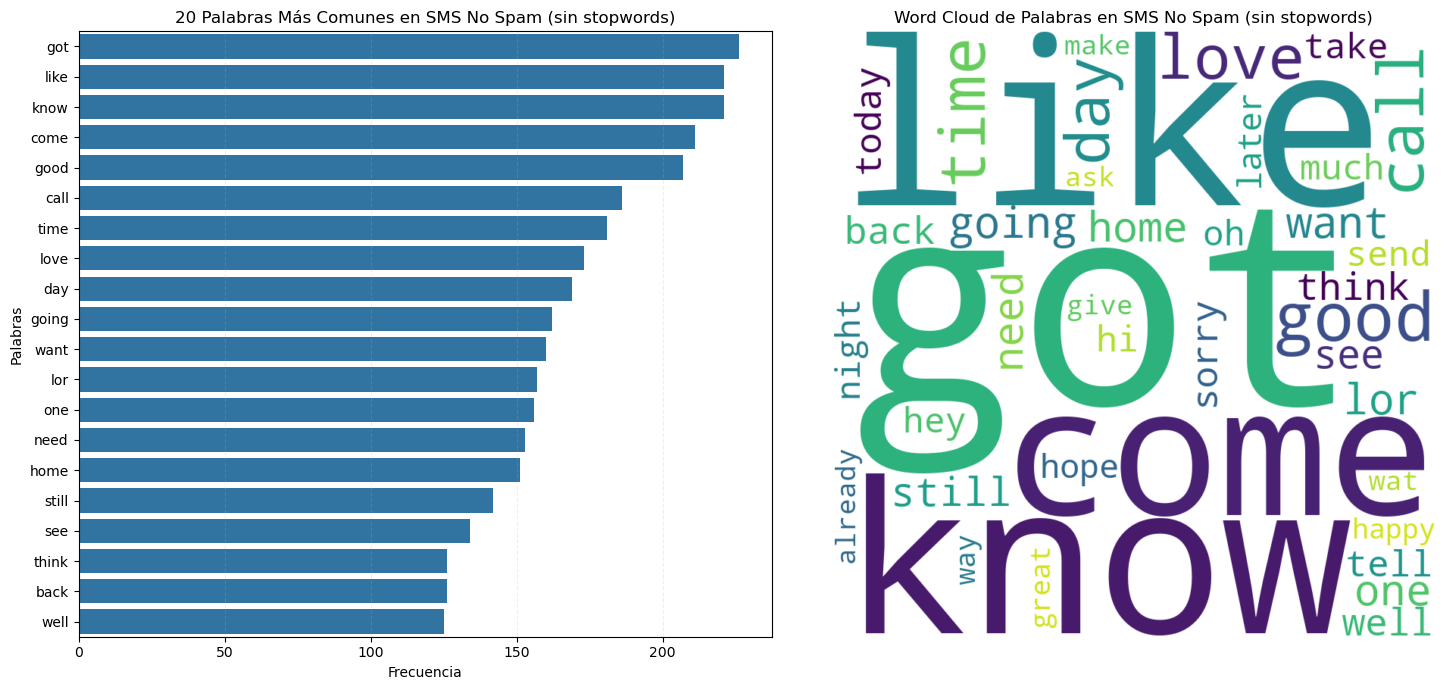

In [55]:
#| label: grafico-barras-wordcloud-no-spam

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(x=[pair[1] for pair in counter_no_spam.most_common(20)], y=[pair[0] for pair in counter_no_spam.most_common(20)], ax=axes[0])
axes[0].set_title('20 Palabras Más Comunes en SMS No Spam (sin stopwords)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Palabras')
axes[0].grid(axis='x', linestyle='--', alpha=0.2)

wordcloud_no_spam = WordCloud(width=800, height=800, background_color='white', max_words=40).generate_from_frequencies(counter_no_spam)
axes[1].imshow(wordcloud_no_spam, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud de Palabras en SMS No Spam (sin stopwords)')

plt.tight_layout()
plt.show()

De la frecuencia de cada palabra podemos extraer la siguiente información valiosa:

- Distribución: La palabra con mayor frecuencia es "got" (226 ocurrencias), descendiendo gradualmente hasta "well" (125). Al no existir un término que domine la distribución, concluimos que el lenguaje en los mensajes SMS válidos es variado y está ampliamente distribuido.
- Vocabulario principal: Las palabras "got", "like", "know", "come" y "good" superan el umbral de las 200 ocurrencias, constituyendo los pilares del vocabulario utilizado.
- Semántica: El vocabulario está dominado principalmente por verbos de acción y estado (got, know, come, see, want, think), conceptos afectivos (love, good) y términos cotidianos (home, day, time).
- Ausencia de patrones de urgencia: Cabe resaltar que, en los mensajes válidos, no se observa vocabulario relacionado con urgencias o transacciones, lo cual indica que los usuarios no suelen emplear términos transaccionales en su comunicación cotidiana vía SMS.
- Análisis complementario: En la nube de palabras (que incluye 40 términos), observamos vocablos adicionales con frecuencias moderadas, tales como "happy", "sorry", "later" y "night". Aunque menos frecuentes, estos términos aportan un significado importante al contexto del mensaje.

Es fundamental aclarar que la frecuencia de aparición de cada palabra no se relaciona directamente con la cantidad de mensajes que la contienen, dado que un mismo mensaje puede incluir la misma palabra en numerosas ocasiones. Este factor debe considerarse para no sobreestimar la representatividad de ciertos términos en el conjunto de datos.

Ahora exploraremos la frecuencia de las palabras en los mensajes etiquetados como SPAM, siguiendo el mismo proceso que aplicamos anteriormente a los mensajes válidos.

In [56]:
counter_spam.most_common(20)

[('call', 303),
 ('free', 188),
 ('txt', 126),
 ('mobile', 105),
 ('stop', 105),
 ('text', 103),
 ('claim', 96),
 ('reply', 93),
 ('prize', 81),
 ('new', 64),
 ('send', 58),
 ('urgent', 58),
 ('nokia', 54),
 ('cash', 51),
 ('contact', 51),
 ('service', 48),
 ('win', 47),
 ('please', 47),
 ('phone', 43),
 ('guaranteed', 42)]

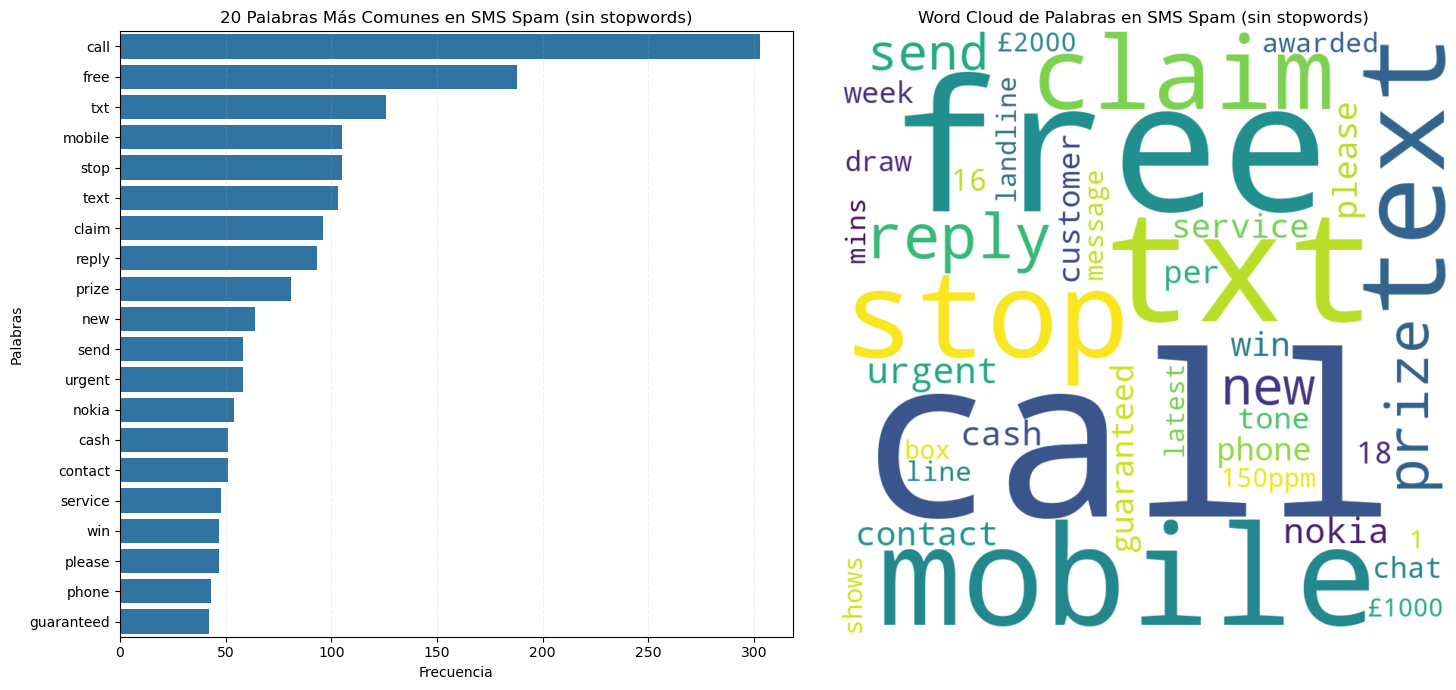

In [57]:
#| label: grafico-barras-wordcloud-spam

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(x=[pair[1] for pair in counter_spam.most_common(20)], y=[pair[0] for pair in counter_spam.most_common(20)], ax=axes[0])
axes[0].set_title('20 Palabras Más Comunes en SMS Spam (sin stopwords)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Palabras')
axes[0].grid(axis='x', linestyle='--', alpha=0.2)

wordcloud_spam = WordCloud(width=800, height=800, background_color='white', max_words=40).generate_from_frequencies(counter_spam)
axes[1].imshow(wordcloud_spam, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud de Palabras en SMS Spam (sin stopwords)')

plt.tight_layout()
plt.show()

De la frecuencia de las palabras en los mensajes etiquetados como SPAM, podemos extraer la siguiente información valiosa:

- Distribución: La palabra "call" domina significativamente, superando las 300 apariciones. Existe una brecha notable entre esta y la siguiente, "free" (188 apariciones). Esto sugiere que el conjunto de datos de spam es bastante monótono y repetitivo, basándose en fórmulas predecibles.
- Vocabulario persuasivo: El léxico está diseñado para activar sesgos cognitivos, organizándose en tres categorías semánticas claras:

    1. Incentivos: Palabras que actúan como gancho (free, prize, cash, win, new).
    2. Urgencia: Términos que presionan al usuario a tomar decisiones inmediatas (urgent, guaranteed, latest).
    3. Llamados a la acción (CTA): Verbos que fuerzan la interacción, tales como call, claim, reply y send. Esto se refuerza con términos tecnológicos y de contacto como mobile, phone, txt, text y contact.

- Nube de palabras: Predominan los términos imperativos y comerciales (call, free, claim, txt, stop), acompañados de valores monetarios como "£1000" o "£2000", utilizados para captar la atención.

La palabra "stop" (105 ocurrencias) merece un análisis particular. Es común que los mensajes de spam incluyan una instrucción para enviar "STOP" y cancelar la suscripción; esta táctica es empleada por los atacantes para validar si el número telefónico está activo. Para profundizar, utilizaremos una tabla cruzada que relacione la presencia de esta palabra con la etiqueta SPAM. Emplearemos el conjunto de datos original (formato string) para facilitar la detección de la cadena exacta "STOP" en mayúsculas, formato estándar utilizado en este tipo de comunicaciones.

In [58]:
pd.crosstab(df['sms'].str.contains('STOP'), df['label'], rownames=['Contiene STOP'], colnames=['Clase'])

Clase,0,1
Contiene STOP,,
False,4517,601
True,1,52


Podemos observar que, de 53 apariciones de la palabra "STOP", 52 han sido etiquetadas como spam y solamente una como mensaje válido (ham). Esto indica que la presencia de la palabra "STOP" eleva la probabilidad de que el mensaje sea spam a casi el 100%. Este hallazgo nos brinda información muy valiosa acerca de la relación entre el uso de palabras en mayúsculas y la clasificación de los mensajes. A continuación, exploraremos si esta relación se mantiene para otras palabras al comparar su uso en mayúsculas frente a minúsculas.

In [59]:
for i in counter_spam.most_common(20):
    tabla_cruzada_minuscula = pd.crosstab(df['sms'].str.contains(i[0]), df['label'], colnames=['Clase'])
    tabla_cruzada_mayuscula = pd.crosstab(df['sms'].str.contains(i[0].upper()), df['label'], colnames=['Clase'])

    print('='*20)
    print('Palabra:', i[0])
    print('='*20)
    if tabla_cruzada_minuscula.shape[0] > 1:
        print('Proporción en minuscula')
        print(f'{tabla_cruzada_minuscula.loc[True]}\n')
    if tabla_cruzada_mayuscula.shape[0] > 1:
         print('Proporción en mayuscula')
         print(f'{tabla_cruzada_mayuscula.loc[True]}\n')
         
    print('---' * 20)

Palabra: call
Proporción en minuscula
Clase
0    204
1    184
Name: True, dtype: int64

Proporción en mayuscula
Clase
0    12
1    21
Name: True, dtype: int64

------------------------------------------------------------
Palabra: free
Proporción en minuscula
Clase
0    59
1    56
Name: True, dtype: int64

Proporción en mayuscula
Clase
0     1
1    90
Name: True, dtype: int64

------------------------------------------------------------
Palabra: txt
Proporción en minuscula
Clase
0    10
1    84
Name: True, dtype: int64

Proporción en mayuscula
Clase
0     2
1    16
Name: True, dtype: int64

------------------------------------------------------------
Palabra: mobile
Proporción en minuscula
Clase
0    12
1    89
Name: True, dtype: int64

Proporción en mayuscula
Clase
0    0
1    1
Name: True, dtype: int64

------------------------------------------------------------
Palabra: stop
Proporción en minuscula
Clase
0    36
1    50
Name: True, dtype: int64

Proporción en mayuscula
Clase
0     1

Respecto a las palabras más comunes en los mensajes etiquetados como SPAM, algunas presentan un comportamiento significativamente distinto según estén escritas en minúsculas o mayúsculas. Como observamos con "STOP", algo similar ocurre con "free": en minúsculas, presenta una distribución equitativa (Ham: 59, Spam: 56), mientras que en mayúsculas, prácticamente todos los mensajes se etiquetan como Spam (Ham: 1, Spam: 90). Un patrón similar sucede con "urgent", que en minúsculas muestra una proporción equilibrada, pero en mayúsculas todos los mensajes son clasificados como SPAM. Este comportamiento se repite, con mayor o menor magnitud, en palabras como "win" y "phone". Considerando solo las 20 palabras más frecuentes en el conjunto de datos de spam, identificamos un patrón claro: el uso de mayúsculas en términos clave aumenta considerablemente la probabilidad de que un mensaje sea clasificado como SPAM. Tendremos esto en cuenta al integrar el modelo predictivo que asignará las etiquetas de 'ham' o 'spam' según el contenido del mensaje.

En cuanto a la pregunta planteada sobre cuáles son las palabras más comunes en cada categoría, podemos concluir lo siguiente:

- Mensajes válidos (ham): Las palabras más utilizadas son "got", "like", "know", "come" y "good". Se destaca que ninguna palabra tiene una dominancia significativa sobre las demás, lo que refleja un vocabulario diverso.
- Mensajes de spam: Las palabras más frecuentes son "call", "free", "txt", "mobile" y "stop", observándose una predominancia marcada de la palabra "call".

Asimismo, concluimos que el vocabulario en los mensajes de spam está diseñado estratégicamente para activar sesgos cognitivos mediante tres componentes: incentivos, urgencia y llamados a la acción. Además, la aparición de términos en mayúsculas como "STOP" o "FREE" eleva la probabilidad de que un mensaje sea etiquetado como SPAM a cerca del 100%.

# 5. División del Conjunto de Datos en Entrenamiento, Validación y Prueba
Una vez finalizado el análisis exploratorio de datos (EDA), dividiremos el conjunto original en tres partes: el conjunto de entrenamiento, que utilizaremos para ajustar los parámetros de los modelos; el de validación, que servirá para comparar el desempeño de las distintas alternativas; y el de prueba, destinado a evaluar el rendimiento final del modelo seleccionado. Para esta división, emplearemos una proporción del 70% para el entrenamiento, mientras que los conjuntos de validación y prueba tendrán una proporción del 15% cada uno.

Es importante señalar que utilizaremos un modelo Naive Bayes. Estos modelos se caracterizan por no requerir un gran volumen de datos para lograr una buena capacidad de generalización; por lo tanto, podríamos reducir el conjunto de entrenamiento si fuera necesario. No obstante, en este caso, mantendremos el 70% de los datos para asegurar un entrenamiento robusto del modelo.

In [60]:
X_train, X_temp, y_train, y_temp = train_test_split(df['sms'], df['label'], test_size=0.3, random_state=18, stratify=df['label'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=18, stratify=y_temp)

Comprobamos cuantas observaciones corresponden al entrenamiento, validación y prueba.

In [61]:
print(f'Cantidad de muestras en el conjunto de entrenamiento: {len(X_train)}')
print(f'Cantidad de muestras en el conjunto de validación: {len(X_val)}')
print(f'Cantidad de muestras en el conjunto de prueba: {len(X_test)}')

Cantidad de muestras en el conjunto de entrenamiento: 3619
Cantidad de muestras en el conjunto de validación: 776
Cantidad de muestras en el conjunto de prueba: 776


Además, dado que el conjunto de datos está muy desbalanceado ya que, aproximadamente el 87% corresponde a mensajes válidos (ham) y alrededor del 13% a spam, debemos asegurarnos de que cada clase mantenga esta misma proporción en los subconjuntos, de lo contrario, existe el riesgo de que alguno de ellos contenga observaciones de una sola clase, afectando la representatividad del entrenamiento.

In [62]:
print(f'proporción de clases en el conjunto de entrenamiento:\n{y_train.value_counts(normalize=True) * 100}\n')
print(f'proporción de clases en el conjunto de validación:\n{y_val.value_counts(normalize=True) * 100}\n')
print(f'proporción de clases en el conjunto de prueba:\n{y_test.value_counts(normalize=True) * 100}\n')

proporción de clases en el conjunto de entrenamiento:
label
0    87.372202
1    12.627798
Name: proportion, dtype: float64

proporción de clases en el conjunto de validación:
label
0    87.371134
1    12.628866
Name: proportion, dtype: float64

proporción de clases en el conjunto de prueba:
label
0    87.371134
1    12.628866
Name: proportion, dtype: float64



# 6. Modelo Base
En esta fase de modelado, llevaremos a cabo los siguientes pasos:

- TF-IDF: Utilizaremos el método *Term Frequency - Inverse Document Frequency*, que consiste en tokenizar cada palabra y vectorizarla según su frecuencia en el mensaje individual, ponderada por su importancia en el corpus completo, la cual esta compuesta por todos los SMS de entrenamiento. Esto nos permitirá obtener una representación numérica de cada palabra, la cual cuantifica su relevancia dentro del contexto general. Estos valores serán fundamentales para que el modelo identifique características diferenciadoras entre los mensajes válidos (ham) y los etiquetados como spam, permitiéndole detectar patrones léxicos para realizar predicciones.
- Complement Naive Bayes: Este modelo es una extensión del clasificador Multinomial Naive Bayes (MNB), diseñado específicamente para conjuntos de datos desbalanceados. A diferencia del modelo estándar, que modela los patrones internos de una clase a partir de sus propios datos, el Complement Naive Bayes calcula la probabilidad de que una característica aparezca en el complemento de dicha clase. Esto permite una clasificación más equitativa para la clase minoritaria, evitando la necesidad de recurrir a técnicas externas como el sobremuestreo.

Implementaremos tanto el método TF-IDF como el modelo Complement Naive Bayes utilizando sus parámetros predeterminados sobre el conjunto de datos crudo.

A continuación, creamos la instancia de `tfidf_vectorizer()`:

In [63]:
tfidf_vectorizer_base = TfidfVectorizer()

Entrenamos y aplicamos el TF-IDF al conjunto de datos de entrenamiento.

In [64]:
X_train_tfidf_base = tfidf_vectorizer_base.fit_transform(X_train)

Comprobamos el tamaño del conjunto de datos de entrenamiento resultante.

In [65]:
X_train_tfidf_base.shape

(3619, 7194)

Obtuvimos un vocabulario compuesto por 7,194 palabras, donde cada una corresponde a una columna del conjunto de datos vectorizado. A continuación, aplicaremos esta transformación al conjunto de datos de validación, utilizando como referencia los parámetros aprendidos durante el entrenamiento.

In [66]:
X_val_tfidf_base = tfidf_vectorizer_base.transform(X_val)

Creamos una instancia del modelo Complement Naive Bayes y lo entrenamos con el conjunto de datos de entrenamiento.

In [67]:
modelo_base = ComplementNB()
modelo_base.fit(X_train_tfidf_base, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


Generamos las predicciones del modelo entrenado sobre el conjunto de validación, con el objetivo de evaluar su desempeño y capacidad de generalización.

In [68]:
y_val_pred_base = modelo_base.predict(X_val_tfidf_base)

Una vez obtenidas las predicciones del modelo Complement Naive Bayes sobre el conjunto de validación, generaremos la matriz de confusión. Esta herramienta nos permitirá visualizar la cantidad de aciertos y errores del modelo al comparar sus predicciones con las etiquetas reales de los mensajes SMS.

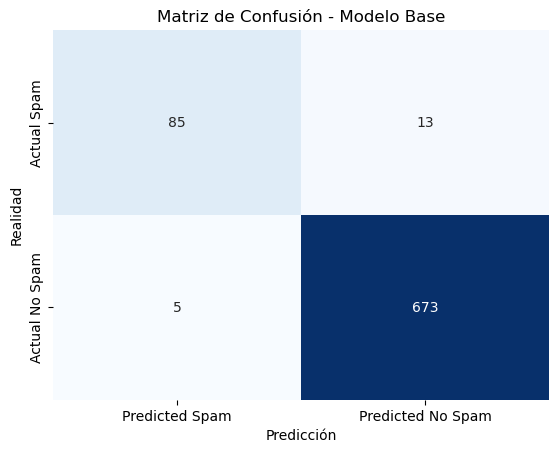

In [69]:
confusion_matrix_base = confusion_matrix(y_val, y_val_pred_base, labels=[1, 0])
sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'])
plt.title('Matriz de Confusión - Modelo Base')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

De la matriz de confusión podemos extraer información valiosa. Primero, identifiquemos los componentes del desempeño de nuestro modelo:

- Verdaderos Positivos (TP): Cantidad de observaciones que el modelo etiquetó correctamente como spam (85).
- Falsos Positivos (FP): Cantidad de observaciones que el modelo etiquetó erróneamente como spam, cuando en realidad eran mensajes válidos (ham) (5).
- Verdaderos Negativos (TN): Cantidad de observaciones que el modelo etiquetó correctamente como mensajes válidos (673).
- Falsos Negativos (FN): Cantidad de observaciones que el modelo etiquetó erróneamente como mensajes válidos, cuando en realidad son spam (13).

A partir de este análisis, podemos concluir lo siguiente:

- Rendimiento: De un total de 98 mensajes que son spam (TP + FN), el modelo identificó correctamente 85. Esto indica que el clasificador ha aprendido efectivamente los patrones léxicos del spam.
- Análisis de Impacto: Es crucial determinar qué tipo de error tiene un menor impacto negativo en el negocio. Si el modelo deja pasar spam (Falsos Negativos), el usuario sufrirá molestias en su bandeja de entrada; sin embargo, si el modelo genera Falsos Positivos (etiquetar como spam un mensaje válido), el usuario corre el riesgo de perder información crítica, por lo tanto, para este caso, un Falso Positivo tiene un impacto negativo mayor. Debemos considerar esta asimetría al momento de seleccionar la métrica final de evaluación.
- Identificación de mensajes válidos: De 678 mensajes válidos, el modelo identificó correctamente 673, catalogando erróneamente solo 5 como spam. A pesar del desbalance de clases, el modelo muestra una alta capacidad para clasificar correctamente los mensajes legítimos.

Para obtener resultados más objetivos, nos centraremos en dos métricas clave que describen el comportamiento del modelo frente a la detección de spam:

- Recall: De todos los mensajes que realmente son spam, cuántos ha predicho correctamente el modelo.
- Precision: De todas las observaciones que el modelo predijo como spam, cuántas lo son realmente.

In [70]:
recall_base = recall_score(y_val, y_val_pred_base)
precision_base = precision_score(y_val, y_val_pred_base)
print(f'Recall del modelo base: {recall_base:.4f}')
print(f'Precision del modelo base: {precision_base:.4f}')

Recall del modelo base: 0.8673
Precision del modelo base: 0.9444


En general, el modelo tiene un desempeño muy alto. Podríamos pensar inicialmente que, si bien de 776 observaciones ha acertado en 758, equivocándose solamente en 18, no estaríamos teniendo en cuenta que el conjunto de datos está desbalanceado. De tal forma que un modelo que etiquete todas las observaciones de acuerdo con la clase dominante tendrá un desempeño alto en la cantidad de aciertos. Por ello, también debemos tener en cuenta (sobre todo en clases desbalanceadas) la proporción de mensajes que el modelo ha etiquetado como spam, obteniendo en este caso un desempeño alto, ya que ha capturado alrededor del 86% de esos mensajes. Además, en cuanto a los mensajes que el modelo ha etiquetado como spam, también tenemos un desempeño alto, ya que ha acertado el 94%.

Esto nos permite concluir que el conjunto de datos cuenta con patrones en el uso de palabras, números, signos de puntuación, etc., que le permiten al modelo, a través del método TF-IDF, identificar las características de los mensajes de spam y válidos. De esta forma, logró capturar sus patrones y mostrar una capacidad de generalización muy buena frente a observaciones que no ha visto el modelo. Además, cabe resaltar que se ha obtenido un desempeño alto utilizando los valores por defecto tanto del método TF-IDF como del modelo Complement Naive Bayes, lo que nos indica que dichos valores se ajustan adecuadamente al conjunto de datos.

Como mencionamos anteriormente respecto a la matriz de confusión y al impacto de los falsos positivos y falsos negativos en el negocio, la equivocación que genera un mayor impacto negativo es cuando el modelo genera un falso positivo (FP); esto quiere decir que el modelo puede etiquetar como spam un mensaje importante para el usuario (como, por ejemplo, una cita médica o información bancaria). Por lo cual, debemos prestar mayor atención a la métrica de Precision, la cual se encarga de medir la relación entre los verdaderos positivos y los falsos positivos, pero sin descuidar la métrica de Recall, ya que un valor bajo en esta significa que al modelo le cuesta identificar los mensajes de spam.

Existe una métrica que resume la Precision y el Recall en un solo puntaje: la métrica F1. Esta combina ambos valores, castigando severamente si alguno de los dos es muy bajo. Sin embargo, esta métrica asume que los falsos positivos y los falsos negativos tienen un impacto similar en el negocio, lo que en este caso no aplica, ya que los falsos positivos tienen un mayor impacto. Para resolver esto, podemos utilizar la métrica F1 añadiéndole un parámetro adicional que nos permita darle más importancia a la Precision. En este caso, le daremos el doble de importancia a la Precision que al Recall.

In [71]:
f05_scorer = make_scorer(fbeta_score, beta=0.5)

Para evaluar el modelo, utilizaremos validación cruzada con el fin de obtener métricas más robustas y confiables sobre su comportamiento. Crearemos una función que nos permita calcular el promedio de las métricas resultantes, junto con sus desviaciones estándar. Lo haremos de la siguiente forma:

In [72]:
def validacion_cruzada(modelo, X, y):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)
    
    scorings = {
        'f1': make_scorer(f1_score),
        'f0.5': f05_scorer
    }
    
    results = cross_validate(modelo, X, y, cv=kf, scoring=scorings)
    
    metrics = {
        'f1_mean': np.mean(results['test_f1']),
        'f1_std': np.std(results['test_f1']),
        'f0.5_mean': np.mean(results['test_f0.5']),
        'f0.5_std': np.std(results['test_f0.5'])
    }
    
    return metrics

In [73]:
pipeline_modelo_base = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('cnb', ComplementNB())
])
metrics_base = validacion_cruzada(pipeline_modelo_base, X_train, y_train)
print(f"F1-score del modelo base (validación cruzada): {metrics_base['f1_mean']:.4f} ± {metrics_base['f1_std']:.4f}")
print(f"F0.5-score del modelo base (validación cruzada): {metrics_base['f0.5_mean']:.4f} ± {metrics_base['f0.5_std']:.4f}")

F1-score del modelo base (validación cruzada): 0.8975 ± 0.0261
F0.5-score del modelo base (validación cruzada): 0.9249 ± 0.0211


De acuerdo con los resultados de la validación cruzada, las métricas F1 obtenidas son muy consistentes; además, presentan una variación de tan solo 0.02%, lo que indica que la evaluación realizada en cada fold es bastante estable.

A continuación, calcularemos las métricas para las predicciones del modelo base obtenidas con el conjunto de validación.

In [74]:
f_05_base = f05_scorer(modelo_base, X_val_tfidf_base, y_val)
print(f'F0.5-score del modelo base: {f_05_base:.4f}')

F0.5-score del modelo base: 0.9279


Esta métrica nos indica que, dándole el doble de importancia a la precisión sobre el recall, hemos obtenido un valor de desempeño bastante alto, demostrando una excelente capacidad de generalización, ya que un valor por encima de 0.8 suele considerarse indicador de un buen modelo. También podemos calcular el F1 estándar de la siguiente forma:

In [75]:
f1_base = f1_score(y_val, y_val_pred_base)
print(f"F1-score del modelo base: {f1_base:.4f}")

F1-score del modelo base: 0.9043


Almacenamos las métricas del modelo base en un DataFrame con el objetivo de comparar, posteriormente, los resultados de distintos modelos con diversas configuraciones.

In [76]:
resumen_modelos = pd.DataFrame({
    'Modelo': ['Modelo Base'],
    'Tamaño TF-IDF': [X_train_tfidf_base.shape[1]],
    'Recall': [round(recall_base, 4)],
    'Precision': [round(precision_base, 4)],
    'F1-score (CV)': [round(metrics_base['f1_mean'], 4)],
    'F1-score stdev (CV)': [round(metrics_base['f1_std'], 4)],
    'F0.5-score (CV)': [round(metrics_base['f0.5_mean'], 4)],
    'F0.5-score stdev (CV)': [round(metrics_base['f0.5_std'], 4)],
    'F1-score (Val)': [round(f1_base, 4)],
    'F0.5-score (Val)': [round(f_05_base, 4)],
})

resumen_modelos

,Modelo,Tamaño TF-IDF,Recall,Precision,F1-score (CV),F1-score stdev (CV),F0.5-score (CV),F0.5-score stdev (CV),F1-score (Val),F0.5-score (Val)
0,Modelo Base,7194,0.8673,0.9444,0.8975,0.0261,0.9249,0.0211,0.9043,0.9279


Una vez obtenidas las métricas más importantes del modelo Complement Naive Bayes, utilizando los hiperparámetros por defecto tanto del método TF-IDF como del modelo, exploraremos diversas configuraciones de hiperparámetros para evaluar su desempeño frente al del modelo base que hemos creado.

# 7. Modelo con Vocabulario Limitado
El modelo base que hemos creado utiliza el vocabulario completo generado por el método TF-IDF aplicado sobre los mensajes SMS, generando una matriz compuesta por 7,194 columnas. Posteriormente, el modelo Complement Naive Bayes fue entrenado utilizando dicha matriz. Sin embargo, es posible que muchas de esas columnas no sean útiles para clasificar correctamente los mensajes; esto puede deberse a que algunas características aparecen solo en un mensaje, o en muy pocos, por lo cual no brindan información suficiente para que el modelo realice mejores predicciones.

Por ello, limitaremos el vocabulario generado por el método TF-IDF (la cantidad de columnas) con el fin de determinar el tamaño necesario para mantener o mejorar las predicciones del modelo base, reduciendo al mismo tiempo la dimensionalidad del conjunto de datos. Esto nos permitirá, en principio, preservar la capacidad de generalización del modelo requiriendo menos recursos para el entrenamiento.

Para analizar el comportamiento de las predicciones según el tamaño del vocabulario, realizaremos varias iteraciones variando este parámetro y empleando validación cruzada para obtener las métricas que nos permitan evaluar el modelo en cada caso.

In [77]:
f_05_scores = []
f_05_std_scores = []
f_01_scores = []
f_01_std_scores = []

tamano_vocabulario = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 7200]

for i in tamano_vocabulario:
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=i)),
        ('cnb', ComplementNB())
    ])
    
    metrics_4000 = validacion_cruzada(pipeline, X_train, y_train)
    
    f_05_scores.append(metrics_4000['f0.5_mean'])
    f_05_std_scores.append(metrics_4000['f0.5_std'])
    f_01_scores.append(metrics_4000['f1_mean'])
    f_01_std_scores.append(metrics_4000['f1_std'])
    print(f"F0.5-score (CV) con vocabulario de {i} palabras: {metrics_4000['f0.5_mean']:.4f} ± {metrics_4000['f0.5_std']:.4f}")
    print(f"F1-score (CV) con vocabulario de {i} palabras: {metrics_4000['f1_mean']:.4f} ± {metrics_4000['f1_std']:.4f}")

F0.5-score (CV) con vocabulario de 1000 palabras: 0.8169 ± 0.0334
F1-score (CV) con vocabulario de 1000 palabras: 0.8630 ± 0.0221
F0.5-score (CV) con vocabulario de 2000 palabras: 0.8590 ± 0.0307
F1-score (CV) con vocabulario de 2000 palabras: 0.8863 ± 0.0259
F0.5-score (CV) con vocabulario de 3000 palabras: 0.8757 ± 0.0362
F1-score (CV) con vocabulario de 3000 palabras: 0.8841 ± 0.0290
F0.5-score (CV) con vocabulario de 4000 palabras: 0.9025 ± 0.0399
F1-score (CV) con vocabulario de 4000 palabras: 0.8977 ± 0.0331
F0.5-score (CV) con vocabulario de 5000 palabras: 0.9110 ± 0.0284
F1-score (CV) con vocabulario de 5000 palabras: 0.8979 ± 0.0279
F0.5-score (CV) con vocabulario de 6000 palabras: 0.9181 ± 0.0256
F1-score (CV) con vocabulario de 6000 palabras: 0.8961 ± 0.0300
F0.5-score (CV) con vocabulario de 7000 palabras: 0.9249 ± 0.0211
F1-score (CV) con vocabulario de 7000 palabras: 0.8975 ± 0.0261
F0.5-score (CV) con vocabulario de 7200 palabras: 0.9249 ± 0.0211
F1-score (CV) con vocabu

Para visualizar mejor la evolución de las métricas ante diferentes tamaños de vocabulario, vamos a crear un gráfico de líneas que nos permita analizar los resultados de cada iteración en función del tamaño del vocabulario utilizado.

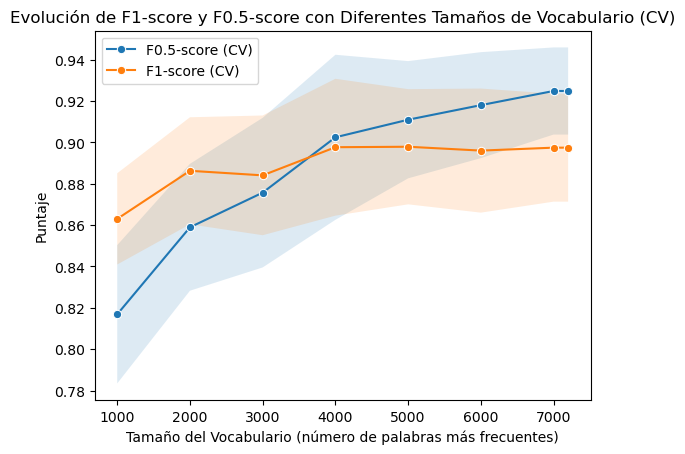

In [78]:
sns.lineplot(x=tamano_vocabulario, y=f_05_scores, marker='o', label='F0.5-score (CV)')
plt.fill_between(tamano_vocabulario, np.array(f_05_scores) - np.array(f_05_std_scores), np.array(f_05_scores) + np.array(f_05_std_scores), alpha=0.15)
sns.lineplot(x=tamano_vocabulario, y=f_01_scores, marker='o', label='F1-score (CV)')
plt.fill_between(tamano_vocabulario, np.array(f_01_scores) - np.array(f_01_std_scores), np.array(f_01_scores) + np.array(f_01_std_scores), alpha=0.15)
plt.title('Evolución de F1-score y F0.5-score con Diferentes Tamaños de Vocabulario (CV)')
plt.xlabel('Tamaño del Vocabulario (número de palabras más frecuentes)')
plt.ylabel('Puntaje')
plt.legend()
plt.show()

A partir del gráfico de líneas podemos extraer la siguiente información:

- Métrica "F1": La línea parte de un valor aproximado de 0.86 con 1000 palabras, lo que nos indica que, al utilizar solamente las 1000 palabras más frecuentes, el modelo ya posee una buena capacidad de predicción para la clasificación. El mayor salto en esta métrica ocurre al incrementar el vocabulario a 2000 palabras, obteniendo un valor aproximado de 0.88; esto nos sugiere que, con este vocabulario, el modelo captura la mayor parte de la información esencial para distinguir entre clases. A partir de las 4000 palabras, la métrica se estabiliza en torno a 0.89; es decir, al agregar más vocabulario, no mejora el equilibrio estándar entre la precisión y el recall del modelo.
- Métrica "F0.5": Esta métrica, que le otorga el doble de importancia a los falsos positivos sobre los falsos negativos, muestra un crecimiento constante y supera a la métrica "F1" al utilizar un vocabulario de 4000 palabras o más. Su rendimiento óptimo se encuentra en el extremo superior derecho, alcanzando un valor de aproximadamente 0.92 con el vocabulario completo.

Este comportamiento indica que añadir palabras menos frecuentes al conjunto de entrenamiento ayuda al modelo a identificar mensajes que no son spam. Esto se debe a que los SMS legítimos suelen tener una variedad léxica o términos particulares que no aparecen en los mensajes masivos de spam; por tanto, un vocabulario más amplio le permite al modelo capturar patrones sutiles para evitar falsas alarmas.

Si tuviéramos que disminuir el tamaño del vocabulario manteniendo el mayor desempeño posible, la opción más adecuada sería establecerlo en 4000 palabras. De esta forma, mantenemos un valor de 0.90 en la métrica "F0.5" (comparado con 0.92 utilizando todo el vocabulario, una diferencia de solo 0.02), empleando únicamente el 55% del total de características generadas por el método TF-IDF. En cuanto a la métrica "F1", obtenemos un valor similar, estableciéndose en 0.897, con una variación mínima en la desviación estándar (pasando de 0.02 a 0.03) al utilizar 4000 palabras del vocabulario total.

In [79]:
f1_score_cv_4000 = f_01_scores[3]
f_01_std_score_cv_4000 = f_01_std_scores[3]
f_05_score_cv_4000 = f_05_scores[3]
f_05_std_score_cv_4000 = f_05_std_scores[3]
print(f"F1-score (CV) con vocabulario de 4000 palabras: {f1_score_cv_4000:.4f} ± {f_01_std_score_cv_4000:.4f}")
print(f"F0.5-score (CV) con vocabulario de 4000 palabras: {f_05_score_cv_4000:.4f} ± {f_05_std_score_cv_4000:.4f}")

F1-score (CV) con vocabulario de 4000 palabras: 0.8977 ± 0.0331
F0.5-score (CV) con vocabulario de 4000 palabras: 0.9025 ± 0.0399


Aplicamos el método TF-IDF utilizando un vocabulario de 4000 palabras, lo entrenamos con el conjunto de datos de entrenamiento y lo aplicamos al conjunto de validación.

In [80]:
tfidf_vectorizer_4000 = TfidfVectorizer(max_features=4000)
X_train_tfidf_4000 = tfidf_vectorizer_4000.fit_transform(X_train)
X_val_tfidf_4000 = tfidf_vectorizer_4000.transform(X_val)

Creamos una instancia del modelo Complement Naive Bayes y lo entrenamos con el conjunto de 4000 características.

In [81]:
modelo_4000 = ComplementNB()
modelo_4000.fit(X_train_tfidf_4000, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


Realizamos las predicciones sobre el conjunto de validación.

In [82]:
y_val_pred_4000 = modelo_4000.predict(X_val_tfidf_4000)

Hallamos las métricas:

In [83]:
recall_4000 = recall_score(y_val, y_val_pred_4000)
precision_4000 = precision_score(y_val, y_val_pred_4000)
f1_4000 = f1_score(y_val, y_val_pred_4000)
f05_4000 = f05_scorer(modelo_4000, X_val_tfidf_4000, y_val)
print(f'Recall con vocabulario de 4000 palabras: {recall_4000:.4f}')
print(f'Precision con vocabulario de 4000 palabras: {precision_4000:.4f}')
print(f'F1-score con vocabulario de 4000 palabras: {f1_4000:.4f}')
print(f'F0.5-score con vocabulario de 4000 palabras: {f05_4000:.4f}')

Recall con vocabulario de 4000 palabras: 0.8980
Precision con vocabulario de 4000 palabras: 0.9072
F1-score con vocabulario de 4000 palabras: 0.9026
F0.5-score con vocabulario de 4000 palabras: 0.9053


Procedemos a colocarla en el DataFrame que contiene los modelos. 

In [84]:
fila_modelo_4000 = pd.DataFrame({
    'Modelo': ['Modelo con vocabulario de 4000 palabras'],
    'Tamaño TF-IDF': [X_train_tfidf_4000.shape[1]],
    'Recall': [round(recall_4000, 4)],
    'Precision': [round(precision_4000, 4)],
    'F1-score (CV)': [round(f1_score_cv_4000, 4)],
    'F1-score stdev (CV)': [round(f_01_std_score_cv_4000, 4)],
    'F0.5-score (CV)': [round(f_05_score_cv_4000, 4)],
    'F0.5-score stdev (CV)': [round(f_05_std_score_cv_4000, 4)],
    'F1-score (Val)': [round(f1_4000, 4)],
    'F0.5-score (Val)': [round(f05_4000, 4)],
})

resumen_modelos = pd.concat([resumen_modelos, fila_modelo_4000], ignore_index=True)

resumen_modelos

,Modelo,Tamaño TF-IDF,Recall,Precision,F1-score (CV),F1-score stdev (CV),F0.5-score (CV),F0.5-score stdev (CV),F1-score (Val),F0.5-score (Val)
0,Modelo Base,7194,0.8673,0.9444,0.8975,0.0261,0.9249,0.0211,0.9043,0.9279
1,Modelo con vocabulario de 4000 palabras,4000,0.8980,0.9072,0.8977,0.0331,0.9025,0.0399,0.9026,0.9053


Comparemos la matriz de confusión del modelo base con la del modelo que utiliza 4,000 palabras del vocabulario, con el fin de observar qué cambios se han producido en las predicciones al limitar el vocabulario a poco más de la mitad.

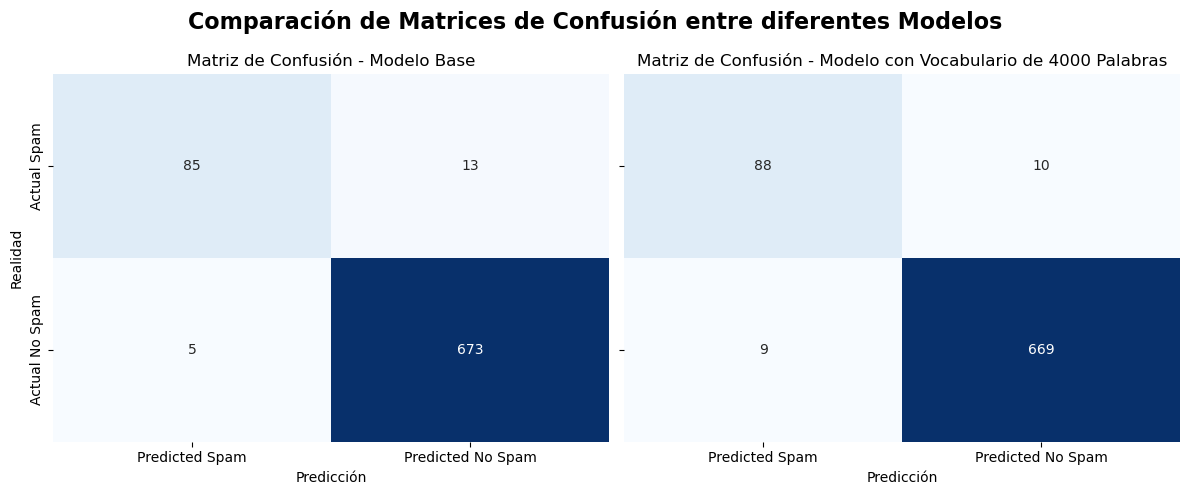

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[0])
axes[0].set_title('Matriz de Confusión - Modelo Base')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Realidad')

confusion_matrix_4000 = confusion_matrix(y_val, y_val_pred_4000, labels=[1, 0])
sns.heatmap(confusion_matrix_4000, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[1])
axes[1].set_title('Matriz de Confusión - Modelo con Vocabulario de 4000 Palabras')
axes[1].set_xlabel('Predicción')

plt.suptitle('Comparación de Matrices de Confusión entre diferentes Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Vemos que, por un lado, han disminuido los falsos negativos: pasamos de 13 mensajes predichos como no spam (cuando en realidad sí lo eran) a solamente 10. Sin embargo, se presenta el comportamiento contrario en cuanto a los falsos positivos, puesto que pasamos de 5 a 9. Este comportamiento en los falsos negativos y positivos explica por qué en la métrica F1 obtenemos valores similares para ambos modelos, mientras que en la métrica que hemos creado, F0.5, el modelo base ha obtenido un mejor desempeño. Esto se debe a que penalizamos más fuertemente los falsos positivos que los falsos negativos.

Aquí cabe realizar un pequeño inciso: se ha realizado la misma prueba con los diferentes tamaños de vocabulario, pero eliminando las *stopwords*. Sin embargo, se han obtenido métricas más bajas. Esto se debe principalmente al estilo de redacción de los mensajes válidos (ham) respecto a los mensajes spam, ya que, cuando son mensajes legítimos, por lo general se suele usar una gran cantidad de pronombres y conectores; esto contrasta con los mensajes de spam, los cuales suelen evitar el uso de pronombres personales informales a favor de estructuras más agresivas enfocadas en la urgencia y el llamado a la acción del usuario.

Entonces, al eliminar las palabras consideradas *stopwords*, estaremos quitándole al modelo la capacidad de detectar el estilo utilizado en un mensaje legítimo. A esto se le suma que la longitud de los mensajes SMS es bastante corta; de forma que, si a un mensaje compuesto de 10 palabras le quitamos 5 *stopwords*, el modelo tendrá solamente 5 palabras con las cuales clasificarlo. En los modelos Naive Bayes, esto hace que el modelo sea inestable y más propenso al error.

# 8. Modelo con Búsqueda en Rejilla de Hiperparametros
Si bien hemos obtenido un desempeño bastante alto con el modelo base y con aquel al que le limitamos el tamaño del vocabulario a través de la configuración de un hiperparámetro, el método TF-IDF cuenta con diversos hiperparámetros que nos permiten refinar la tokenización y vectorización de los elementos que componen un mensaje SMS. Asimismo, el modelo Complement Naive Bayes cuenta con hiperparámetros que podemos ajustar con la finalidad de obtener mejores resultados en la evaluación del desempeño del modelo.

Para llevar a cabo esta búsqueda, crearemos una rejilla con las principales opciones de configuración del método TF-IDF y del modelo Complement Naive Bayes, de tal forma que realizaremos una búsqueda que maximice la métrica "F0.5" que hemos creado, obteniendo como resultado la configuración de hiperparámetros que maximice el rendimiento de dicha métrica.

In [86]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('cnb', ComplementNB())
])

param_grid = {
    'tfidf__max_df': [0.9, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [None, 4000, 5000],
    'tfidf__tokenizer': [None, word_tokenize],
    'tfidf__binary': [True, False],
    'tfidf__sublinear_tf': [True, False],
    'cnb__alpha': [0.1, 0.5, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring=f05_scorer, n_jobs=-1)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...plementNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'cnb__alpha': [0.1, 0.5, ...], 'tfidf__binary': [True, False], 'tfidf__max_df': [0.9, 1.0], 'tfidf__max_features': [None, 4000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f...ct', beta=0.5)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, 



Una vez realizada la búsqueda, vamos a imprimir la mejor configuración de hiperparámetros hallada mediante la búsqueda por rejilla, junto con el resultado de la mejor métrica 'F0.5' obtenida.

In [87]:
print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F0.5-score: {grid_search.best_score_}')

Mejores hiperparámetros: {'cnb__alpha': 0.5, 'tfidf__binary': True, 'tfidf__max_df': 0.9, 'tfidf__max_features': None, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'tfidf__tokenizer': <function word_tokenize at 0x7a304b629d20>}
Mejor F0.5-score: 0.9515212301198511


Ahora, sobre ese modelo que hemos hallado, vamos a realizar la validación cruzada para obtener las métricas 'F1' y 'F0.5' robustas que representen de mejor forma el comportamiento de este modelo.

In [88]:
metrics_grid = validacion_cruzada(grid_search.best_estimator_, X_train, y_train)
print(f"F1-score del modelo con GridSearchCV (validación cruzada): {metrics_grid['f1_mean']:.4f} ± {metrics_grid['f1_std']:.4f}")
print(f"F0.5-score del modelo con GridSearchCV (validación cruzada): {metrics_grid['f0.5_mean']:.4f} ± {metrics_grid['f0.5_std']:.4f}")

F1-score del modelo con GridSearchCV (validación cruzada): 0.8967 ± 0.0137
F0.5-score del modelo con GridSearchCV (validación cruzada): 0.9515 ± 0.0081


En cuanto a la métrica 'F1', hemos obtenido un valor muy similar al de los otros modelos, situándose en 0.896 frente a 0.897; además, la desviación estándar es bastante baja, situándose en torno a 0.01, lo que nos indica que los resultados son estables. Por otro lado, en la métrica 'F0.5', hemos obtenido un valor de 0.951, siendo el modelo con mejor rendimiento en esta métrica; además, posee una desviación estándar menor a una unidad (0.0081), lo que nos indica que es un modelo muy estable, logrando una baja varianza y un bajo sesgo.

Vamos a evaluar el modelo con el conjunto de validación para obtener las métricas de desempeño.

In [89]:
y_val_grid_pred = grid_search.predict(X_val)

In [90]:
f_05_grid = f05_scorer(grid_search.best_estimator_, X_val, y_val)
f1_grid = f1_score(y_val, y_val_grid_pred)
print(f'F0.5-score del modelo con GridSearchCV: {f_05_grid:.4f}')
print(f'F1-score del modelo con GridSearchCV: {f1_grid:.4f}')

F0.5-score del modelo con GridSearchCV: 0.9677
F1-score del modelo con GridSearchCV: 0.9231


En los resultados de las métricas evaluadas sobre el conjunto de validación, hay un ligero aumento en comparación con los obtenidos en la validación cruzada. Esto puede deberse a la división realizada entre el conjunto de entrenamiento y el de validación, la cual, en este caso, ha favorecido los resultados sobre este subconjunto; sin embargo, dicho resultado sigue siendo representativo del modelo.

Compararemos los resultados con los de los otros modelos mediante la matriz de confusión que hemos generado para cada uno.

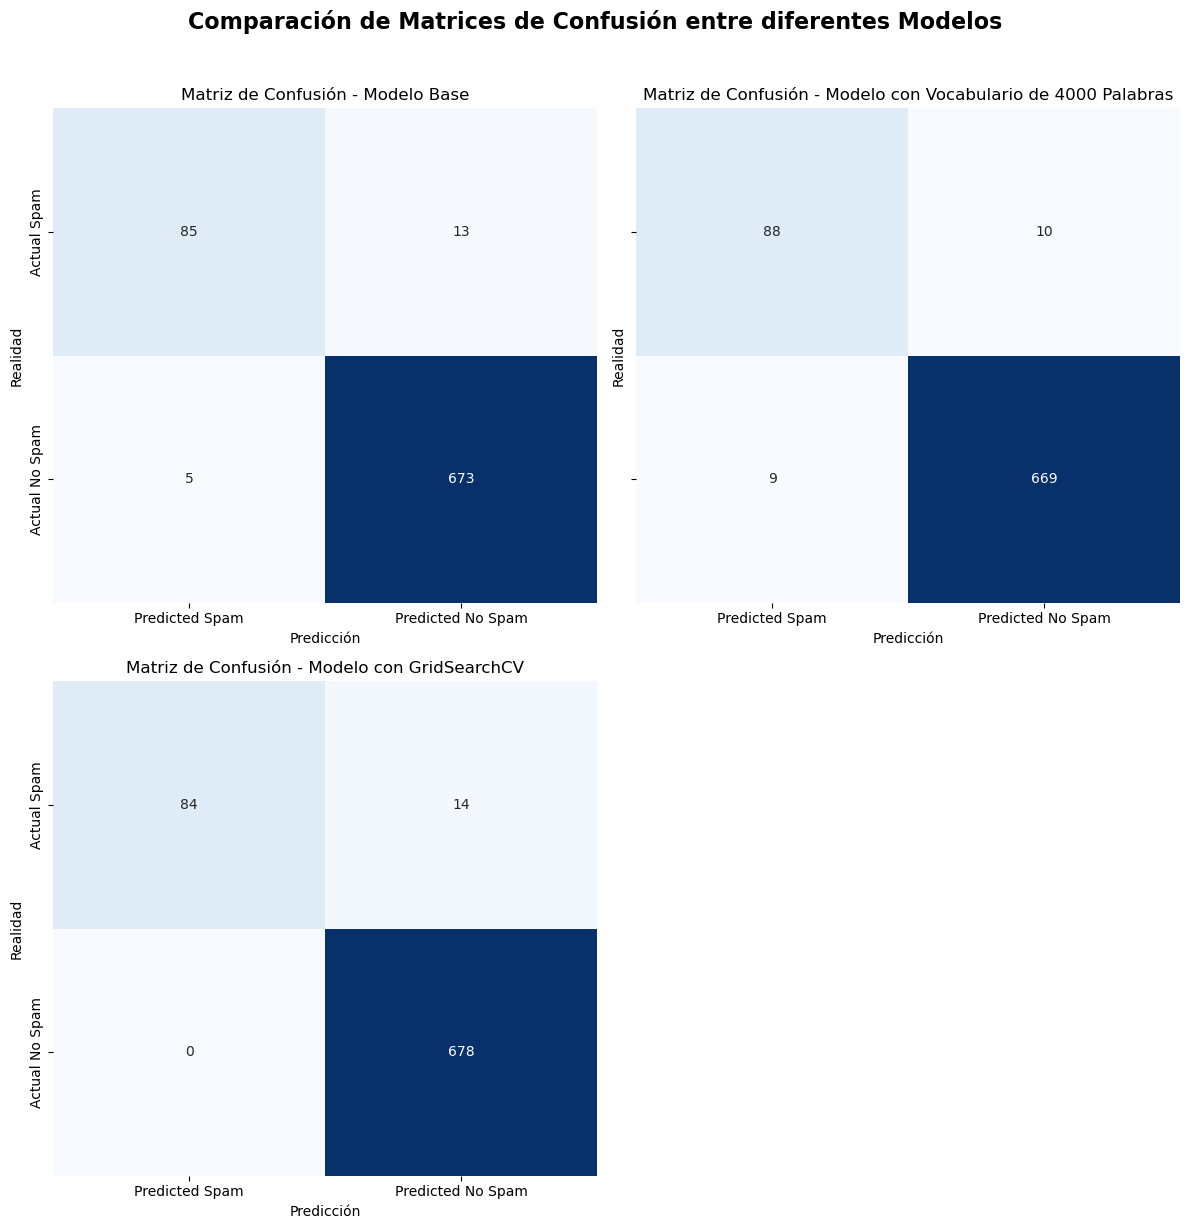

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)


sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión - Modelo Base')
axes[0,0].set_xlabel('Predicción')
axes[0,0].set_ylabel('Realidad')

confusion_matrix_4000 = confusion_matrix(y_val, y_val_pred_4000, labels=[1, 0])
sns.heatmap(confusion_matrix_4000, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[0,1])
axes[0,1].set_title('Matriz de Confusión - Modelo con Vocabulario de 4000 Palabras')
axes[0,1].set_xlabel('Predicción')
axes[0,1].set_ylabel('Realidad')

confusion_matrix_grid = confusion_matrix(y_val, y_val_grid_pred, labels=[1, 0])
sns.heatmap(confusion_matrix_grid, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[1,0])
axes[1,0].set_title('Matriz de Confusión - Modelo con GridSearchCV')
axes[1,0].set_xlabel('Predicción')
axes[1,0].set_ylabel('Realidad')

plt.delaxes(axes[1,1]) 

plt.suptitle('Comparación de Matrices de Confusión entre diferentes Modelos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

De la comparación de las matrices de confusión que hemos hallado para cada modelo, podemos observar lo siguiente:

- GridSearch: De todos los modelos, este ha sido el único que no ha obtenido ningún falso positivo, eliminando por completo el error que genera mayor impacto en el negocio. Esto se debe a la búsqueda por rejilla, que maximizó la métrica personalizada que penaliza los falsos positivos sobre los falsos negativos.
- Vs. Modelo Base: En comparación con el modelo base, tan solo hemos aumentado un falso negativo; a cambio, hemos pasado de 5 falsos positivos a 0.
- Vs. Modelo de 4000 palabras: El modelo GridSearch ha aumentado en 4 los falsos negativos frente al modelo con vocabulario de 4000 palabras, pero, en cuanto a los falsos positivos, los ha disminuido notablemente de 9 a 0.

Hasta este punto, el modelo GridSearch es el que ha obtenido el mejor desempeño de acuerdo con nuestra métrica, la cual penaliza más fuertemente los falsos positivos. Por lo tanto, resulta ser el modelo más óptimo para nuestro caso de estudio y lógica de negocio.

Finalmente, añadimos las métricas del modelo GridSearch al DataFrame que contiene los resultados de todos los modelos evaluados.

In [92]:
fila_modelo_grid = pd.DataFrame({
    'Modelo': ['Modelo con GridSearchCV'],
    'Tamaño TF-IDF': [grid_search.best_estimator_.named_steps['tfidf'].idf_.shape[0]],
    'Recall': [round(recall_score(y_val, y_val_grid_pred), 4)],
    'Precision': [round(precision_score(y_val, y_val_grid_pred), 4)],
    'F1-score (CV)': [round(metrics_grid['f1_mean'], 4)],
    'F1-score stdev (CV)': [round(metrics_grid['f1_std'], 4)],
    'F0.5-score (CV)': [round(metrics_grid['f0.5_mean'], 4)],
    'F0.5-score stdev (CV)': [round(metrics_grid['f0.5_std'], 4)],
    'F1-score (Val)': [round(f1_grid, 4)],
    'F0.5-score (Val)': [round(f_05_grid, 4)],
})

resumen_modelos = pd.concat([resumen_modelos, fila_modelo_grid], ignore_index=True)

resumen_modelos

,Modelo,Tamaño TF-IDF,Recall,Precision,F1-score (CV),F1-score stdev (CV),F0.5-score (CV),F0.5-score stdev (CV),F1-score (Val),F0.5-score (Val)
0,Modelo Base,7194,0.8673,0.9444,0.8975,0.0261,0.9249,0.0211,0.9043,0.9279
1,Modelo con vocabulario de 4000 palabras,4000,0.8980,0.9072,0.8977,0.0331,0.9025,0.0399,0.9026,0.9053
2,Modelo con GridSearchCV,42781,0.8571,1.0000,0.8967,0.0137,0.9515,0.0081,0.9231,0.9677


Aquí vemos un aspecto muy importante: si bien el modelo de GridSearch logra la métrica 'F0.5' más alta de todos, la matriz TF-IDF generada consta de 42,781 columnas. Es decir, posee una matriz de entrenamiento con aproximadamente 6 veces más columnas que el modelo base. Esto se debe a que la configuración óptima hallada por la búsqueda en rejilla establece los n-gramas en (1,2); es decir, además de capturar las palabras de forma individual, también captura pares de palabras, lo que aumenta exponencialmente el vocabulario de la matriz TF-IDF generada.

Este cambio representa un incremento de solo alrededor del 0.03% en el rendimiento global del modelo, lo cual podría no justificar su implementación. Si buscamos la máxima precisión, el modelo de GridSearch es la mejor opción; sin embargo, si buscamos un equilibrio entre el rendimiento del modelo y los recursos utilizados, el modelo con vocabulario limitado logra grandes resultados con una fracción mínima de columnas de entrenamiento.

# 9. Modelo con Estandarización de caracteristicas


Por último, crearemos un modelo con los mensajes SMS estandarizados, realizando algunas transformaciones sobre el conjunto de entrenamiento con la finalidad de evaluar la capacidad de generalización del modelo una vez que hayamos introducido algunos cambios. Comenzaremos creando una copia de los datos de entrenamiento:

In [93]:
X_train_transformado = X_train.copy()

La primera transformación que realizaremos sobre el conjunto de entrenamiento será el tratamiento de las palabras en mayúsculas. Puesto que durante el análisis exploratorio de datos (EDA) exploramos cómo influye el hecho de que algunas palabras estén escritas en mayúsculas para que sean etiquetadas como spam, la lógica de negocio que vamos a aplicar consistirá en que, si una palabra está compuesta de más de dos letras y está totalmente en mayúsculas, se mantendrá así; sin embargo, si solo una parte de la palabra está en mayúsculas (por ejemplo, solamente la primera letra), entonces toda la palabra se estandarizará a minúsculas.

Crearemos una función que cumpla esta tarea y, posteriormente, la aplicaremos sobre el conjunto de entrenamiento.

In [94]:
def procesar_mayusculas(texto):
    def evaluar_palabra(match):
        palabra = match.group(0)
        if palabra.isupper() and len(palabra) > 2:
            return palabra  
        return palabra.lower()  

    return re.sub(r'\b\w+\b', evaluar_palabra, texto)

In [95]:
X_train_transformado = X_train_transformado.apply(procesar_mayusculas)

Otra transformación que realizaremos consistirá en reemplazar las URLs que sean detectadas en cada mensaje SMS; estas se reemplazarán con la palabra 'URL_TOKEN'. Esto tiene la finalidad de que el modelo Complement Naive Bayes pueda detectar correctamente cuándo un mensaje contiene una URL, de tal forma que diferentes URLs sean reconocidas de la misma forma por el método TF-IDF. De igual forma, crearemos la función para, posteriormente, aplicarla sobre el conjunto de entrenamiento.

In [96]:
def reemplazar_urls(mensaje):
    extractor = URLExtract()
    urls = extractor.find_urls(mensaje)
    
    for url in sorted(urls, key=len, reverse=True):
        mensaje = mensaje.replace(url, ' URL_TOKEN ')
        
    return mensaje

In [97]:
X_train_transformado = X_train_transformado.apply(reemplazar_urls)

El siguiente paso que realizaremos también surge de lo detectado durante la fase del análisis exploratorio de datos (EDA), en la cual identificamos que los mensajes terminan con los caracteres '\n', que representan un salto de línea y no aportan ninguna información relevante al modelo, por lo cual vamos a eliminarlos.

In [98]:
X_train_transformado = X_train_transformado.replace('\n', ' ', regex=True)

La última transformación que realizaremos será estandarizar los números que aparecen en los mensajes SMS, de tal forma que podamos segmentarlos de acuerdo con su longitud, la cantidad de caracteres y si son precedidos por un signo. En este caso, la lógica que utilizaremos es la siguiente:

- Si tiene el signo '$', '£' o '€' antes o después del número, entonces lo reemplazaremos por la palabra "MONEY_TOKEN".
- Si el número está compuesto por un rango de 7 a 11 dígitos, lo reemplazaremos por la palabra "PHONE_TOKEN".
- Si está compuesto por un rango de 4 a 6 dígitos, lo reemplazaremos por la palabra "CODE_TOKEN".
- Si el número está compuesto por menos de 4 dígitos, será reemplazado por "NUM_TOKEN".

Entonces, vamos a crear la función y la aplicaremos sobre el conjunto de datos de entrenamiento.

In [99]:
def transformacion_numeros(mensaje):
    mensaje = re.sub(r'[€$£]\s?\d+([.,]\d+)*|\d+([.,]\d+)*\s?[€$£]', ' MONEY_TOKEN ', mensaje)
    mensaje = re.sub(r'\b\d{7,11}\b', ' PHONE_TOKEN ', mensaje)
    mensaje = re.sub(r'\b\d{4,6}\b', ' CODE_TOKEN ', mensaje)
    mensaje = re.sub(r'\b\d+[\.,]?\d*\b|\b\d+\b', ' NUM_TOKEN ', mensaje)
    mensaje = re.sub(r'\s+', ' ', mensaje).strip()
    return mensaje

In [100]:
X_train_transformado =  X_train_transformado.apply(transformacion_numeros)

Ahora que hemos realizado todas las transformaciones, vamos a realizar una búsqueda en rejilla con la finalidad de encontrar la mejor combinación de hiperparámetros que maximicen la métrica 'F0.5' que hemos establecido; lo haremos de la misma forma en que lo hemos hecho con el modelo GridSearch que generamos anteriormente.

In [101]:
pipeline_modelo_transformado = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('cnb', ComplementNB())
])

param_grid = {
    'tfidf__max_df': [0.9, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [None, 4000, 5000],
    'tfidf__tokenizer': [None, word_tokenize],
    'tfidf__binary': [True, False],
    'tfidf__sublinear_tf': [True, False],
    'cnb__alpha': [0.1, 0.5, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

grid_search_transformado = GridSearchCV(estimator=pipeline_modelo_transformado, param_grid=param_grid, cv=cv, scoring=f05_scorer, n_jobs=-1)

grid_search_transformado.fit(X_train_transformado, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...plementNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'cnb__alpha': [0.1, 0.5, ...], 'tfidf__binary': [True, False], 'tfidf__max_df': [0.9, 1.0], 'tfidf__max_features': [None, 4000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f...ct', beta=0.5)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, 

Una vez que hemos hallado la mejor combinación de hiperparámetros de acuerdo con las opciones que hemos establecido en la búsqueda en rejilla, vamos a imprimir la configuración de los mejores hiperparámetros y la mejor métrica obtenida a partir de dicha búsqueda.

In [102]:
print(f'Mejores hiperparámetros: {grid_search_transformado.best_params_}')
print(f'Mejor F0.5-score: {grid_search_transformado.best_score_}')

Mejores hiperparámetros: {'cnb__alpha': 0.5, 'tfidf__binary': False, 'tfidf__max_df': 0.9, 'tfidf__max_features': None, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'tfidf__tokenizer': <function word_tokenize at 0x7a304b629d20>}
Mejor F0.5-score: 0.9609148758420873


Hemos obtenido una métrica muy similar a la del modelo anterior, apenas 0.005 superior; es decir, con las transformaciones realizadas, hemos obtenido un rendimiento muy parecido al que se obtendría sin aplicar dichas transformaciones antes del entrenamiento. Además, al igual que en el modelo anterior, el hiperparámetro n-gram está en (1,2), lo que aumentará exponencialmente la cantidad de columnas resultantes de la matriz TF-IDF. Ahora, vamos a realizar la validación cruzada para comprobar qué tan estable es la métrica obtenida en la búsqueda en rejilla.

In [103]:

metrics_modelo_transformado = validacion_cruzada(grid_search_transformado.best_estimator_, X_train_transformado, y_train)
print(f"F1-score del modelo con URLs reemplazadas (validación cruzada): {metrics_modelo_transformado['f1_mean']:.4f} ± {metrics_modelo_transformado['f1_std']:.4f}")
print(f"F0.5-score del modelo con URLs reemplazadas (validación cruzada): {metrics_modelo_transformado['f0.5_mean']:.4f} ± {metrics_modelo_transformado['f0.5_std']:.4f}")

F1-score del modelo con URLs reemplazadas (validación cruzada): 0.9240 ± 0.0228
F0.5-score del modelo con URLs reemplazadas (validación cruzada): 0.9609 ± 0.0137


Las métricas obtenidas son bastante estables, presentando una varianza y un sesgo bajos, lo que arroja excelentes resultados. Ahora, vamos a realizar las predicciones sobre el conjunto de validación; para ello, aplicaremos primero las mismas transformaciones que realizamos en el conjunto de entrenamiento. Aquí cabe aclarar que, al ser transformaciones basadas en reglas estáticas, es válido realizarlas sobre el conjunto de validación sin riesgo de fuga de datos.

In [104]:
y_val_transformado = X_val.copy()
y_val_transformado = y_val_transformado.apply(procesar_mayusculas)
y_val_transformado = y_val_transformado.apply(reemplazar_urls)
y_val_transformado = y_val_transformado.replace('\n', ' ', regex=True)
y_val_transformado = y_val_transformado.apply(transformacion_numeros)

Realizamos las predicciones sobre el conjunto de validación y hallamos las métricas 'F1' y 'F0.5'.

In [105]:
y_val_transformado_pred = grid_search_transformado.predict(y_val_transformado)

In [106]:
f_05_transformado = f05_scorer(grid_search_transformado.best_estimator_, y_val_transformado, y_val)
f1_transformado = f1_score(y_val, y_val_transformado_pred)
print(f'F0.5-score del modelo con URLs reemplazadas: {f_05_transformado:.4f}')
print(f'F1-score del modelo con URLs reemplazadas: {f1_transformado:.4f}')

F0.5-score del modelo con URLs reemplazadas: 0.9692
F1-score del modelo con URLs reemplazadas: 0.9412


Obtenemos unas métricas muy similares a las que hemos obtenido de la validación cruzada; esto se debe a que es un modelo que presenta una baja varianza, por lo que los resultados sobre diferentes conjuntos de prueba resultan ser similares.

Calcularemos la matriz de confusión y la compararemos con las demás matrices de confusión que hemos obtenido de los demás modelos que hemos generado.

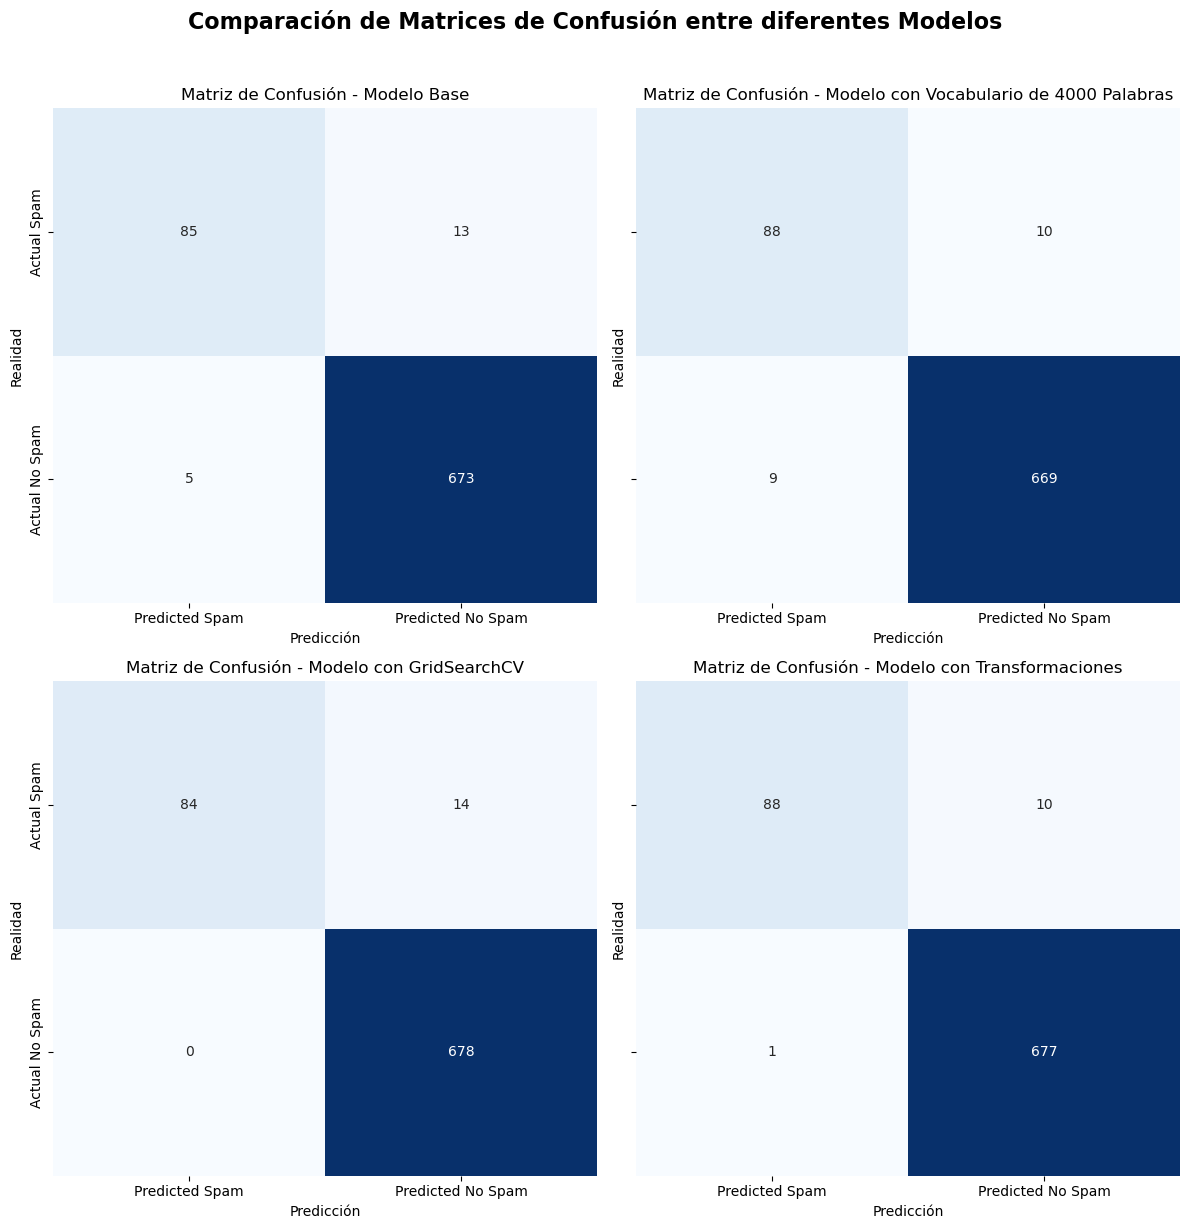

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)


sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión - Modelo Base')
axes[0,0].set_xlabel('Predicción')
axes[0,0].set_ylabel('Realidad')

confusion_matrix_4000 = confusion_matrix(y_val, y_val_pred_4000, labels=[1, 0])
sns.heatmap(confusion_matrix_4000, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[0,1])
axes[0,1].set_title('Matriz de Confusión - Modelo con Vocabulario de 4000 Palabras')
axes[0,1].set_xlabel('Predicción')
axes[0,1].set_ylabel('Realidad')

confusion_matrix_grid = confusion_matrix(y_val, y_val_grid_pred, labels=[1, 0])
sns.heatmap(confusion_matrix_grid, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[1,0])
axes[1,0].set_title('Matriz de Confusión - Modelo con GridSearchCV')
axes[1,0].set_xlabel('Predicción')
axes[1,0].set_ylabel('Realidad')

confusion_matrix_transformado = confusion_matrix(y_val, y_val_transformado_pred, labels=[1, 0])
sns.heatmap(confusion_matrix_transformado, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'], ax=axes[1,1])
axes[1,1].set_title('Matriz de Confusión - Modelo con Transformaciones')
axes[1,1].set_xlabel('Predicción')
axes[1,1].set_ylabel('Realidad')


plt.suptitle('Comparación de Matrices de Confusión entre diferentes Modelos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En relación con la matriz de confusión que hemos hallado para el modelo con transformaciones respecto a los demás modelos, podemos observar los siguientes hallazgos:

- Capacidad de generalización: El modelo con transformaciones tiene una mejor capacidad de generalización respecto al modelo base y al modelo limitado con un vocabulario de 4000 palabras, debido a que se equivoca en menor cantidad de ocasiones.
- Análisis de impacto: Los resultados del modelo con transformaciones son muy similares a los del modelo con GridSearch, puesto que el modelo con transformaciones disminuye en 4 la cantidad de falsos negativos, pero aumenta en 1 la cantidad de falsos positivos. Aquí debemos evaluar cuál tiene mayor impacto en el negocio: ¿permitir 4 mensajes en la bandeja de entrada que en realidad son spam, o etiquetar un mensaje como spam cuando en realidad no lo es? Para este caso, se considera que tiene mayor impacto negativo etiquetar un mensaje como spam cuando no lo es que dejar pasar 4 mensajes que sí son spam a la bandeja de entrada.

Ahora, vamos a agregar este modelo que hemos creado al DataFrame que contiene todos los modelos que hemos generado en este estudio.

In [108]:
fila_modelo_transformado = pd.DataFrame({
    'Modelo': ['Modelo con Transformaciones'],
    'Tamaño TF-IDF': [grid_search_transformado.best_estimator_.named_steps['tfidf'].idf_.shape[0]],
    'Recall': [round(recall_score(y_val, y_val_transformado_pred), 4)],
    'Precision': [round(precision_score(y_val, y_val_transformado_pred), 4)],
    'F1-score (CV)': [round(metrics_modelo_transformado['f1_mean'], 4)],
    'F1-score stdev (CV)': [round(metrics_modelo_transformado['f1_std'], 4)],
    'F0.5-score (CV)': [round(metrics_modelo_transformado['f0.5_mean'], 4)],
    'F0.5-score stdev (CV)': [round(metrics_modelo_transformado['f0.5_std'], 4)],
    'F1-score (Val)': [round(f1_transformado, 4)],
    'F0.5-score (Val)': [round(f_05_transformado, 4)],
})

resumen_modelos = pd.concat([resumen_modelos, fila_modelo_transformado], ignore_index=True)

In [109]:
#| label: tbl-resultados-modelos
#| tbl-cap: "Resumen de Resultados de los Modelos"

resumen_modelos

,Modelo,Tamaño TF-IDF,Recall,Precision,F1-score (CV),F1-score stdev (CV),F0.5-score (CV),F0.5-score stdev (CV),F1-score (Val),F0.5-score (Val)
0,Modelo Base,7194,0.8673,0.9444,0.8975,0.0261,0.9249,0.0211,0.9043,0.9279
1,Modelo con vocabulario de 4000 palabras,4000,0.8980,0.9072,0.8977,0.0331,0.9025,0.0399,0.9026,0.9053
2,Modelo con GridSearchCV,42781,0.8571,1.0000,0.8967,0.0137,0.9515,0.0081,0.9231,0.9677
3,Modelo con Transformaciones,41112,0.8980,0.9888,0.9240,0.0228,0.9609,0.0137,0.9412,0.9692


El modelo con transformaciones, debido a la estandarización que realizamos, hace uso de alrededor de 1500 características menos que el modelo GridSearch. También podemos notar que, en cuanto a la desviación estándar de la métrica 'F1' y la métrica 'F0.5' respecto al modelo GridSearch, el modelo con transformaciones tiene un ligero aumento en la desviación estándar.

Con base en el análisis realizado y la comparación de los modelos a través de la matriz de confusión y el cálculo de algunas métricas como Recall, precisión, F1 y F0.5, teniendo en cuenta la lógica de negocio y el impacto de las diferentes equivocaciones que pueda presentar el modelo, se ha seleccionado el modelo GridSearch como el más adecuado para implementar en el caso de estudio.

# 10. Modelo Final
Hemos elegido el modelo GridSearch como el más adecuado para nuestro caso de estudio; por ello, utilizaremos este modelo para realizar predicciones sobre el conjunto de datos de prueba. Estos son datos que el modelo nunca ha visto, de tal forma que nos brindarán información sobre su comportamiento una vez que esté en producción.

In [110]:
modelo_final = grid_search.best_estimator_

Realizamos las predicciones del modelo sobre el conjunto de datos de prueba

In [111]:
X_test_pred = modelo_final.predict(X_test)

Ahora vamos a calcular las métricas de evaluación 'F1' y la que hemos establecido nosotros, 'F0.5', que penaliza más fuertemente a los falsos positivos sobre los falsos negativos.

In [112]:
f_05_test = f05_scorer(modelo_final, X_test, y_test)
f1_test = f1_score(y_test, X_test_pred)
print(f'F0.5-score del modelo final en el conjunto de prueba: {f_05_test:.4f}')
print(f'F1-score del modelo final en el conjunto de prueba: {f1_test:.4f}')

F0.5-score del modelo final en el conjunto de prueba: 0.9479
F1-score del modelo final en el conjunto de prueba: 0.8939


Hemos obtenido valores de 'F1' y 'F0.5' muy similares a los obtenidos en las métricas de la validación cruzada; esto se debe a que el modelo presenta una baja varianza y un bajo sesgo, logrando un alto desempeño en su capacidad de generalización y generando predicciones muy acertadas sobre los mensajes SMS.

Vamos a crear la matriz de confusión final de este modelo de acuerdo con los resultados obtenidos en el conjunto de datos de prueba.

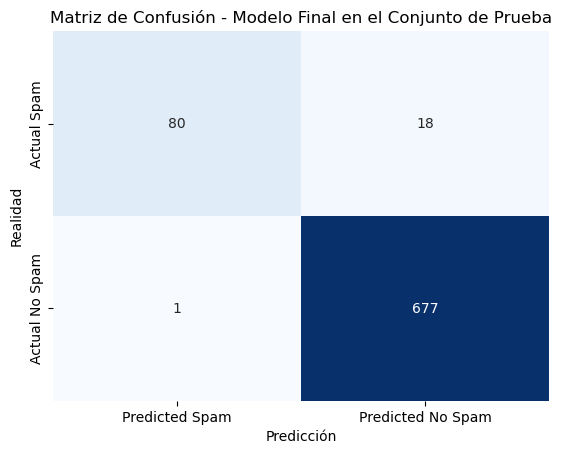

In [113]:
#| label: grafico-matriz-confusion-test

confusion_matrix_test = confusion_matrix(y_test, X_test_pred, labels=[1, 0])
sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Predicted Spam', 'Predicted No Spam'], yticklabels=['Actual Spam', 'Actual No Spam'])
plt.title('Matriz de Confusión - Modelo Final en el Conjunto de Prueba')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

Podemos observar que el modelo ha tenido 19 equivocaciones, de las cuales 18 corresponden a falsos negativos (es decir, el modelo predijo que no eran spam pero en realidad sí lo eran) y solamente 1 falso positivo (donde el modelo predijo que el mensaje era spam pero en realidad no lo era). Esto evidencia la importancia que le hemos asignado a cada equivocación del modelo, evitando al máximo posible que cometa falsos positivos, lo cual está alineado con el negocio; esto, gracias a la métrica 'F0.5' que hemos creado para medir el desempeño de los modelos. Este modelo final resulta ser muy útil para clasificar los mensajes SMS en spam o no spam basándose en el contenido del mensaje.

# 11. Conclusiones
A través de todo el análisis y modelado que hemos realizado en el conjunto de datos SMS, podemos concluir lo siguiente:

- **Descripción del conjunto de datos**: Está conformado por 5.573 observaciones, de las cuales se han eliminado 403 debido a que son mensajes duplicados. Además, presenta un gran desbalance a favor de los mensajes válidos, los cuales representan aproximadamente el 87% de todas las observaciones, mientras que los mensajes de spam representan alrededor del 13% restante.
- **¿Tiene que ver la longitud del mensaje con su etiqueta (spam vs. ham)?**: Si bien la longitud de los mensajes de spam es ligeramente mayor a la de los mensajes válidos, las distribuciones se superponen, lo que indica que no hay un umbral o regla clara que podamos establecer para etiquetar los mensajes de acuerdo con su longitud. La mediana de los mensajes válidos se ubica en alrededor de 10 palabras, mientras que la de los mensajes de spam se ubica en alrededor de 25.
- **¿Existen patrones de lenguaje (uso de mayúsculas, signos especiales o números) que diferencien spam de ham?**:

    - **Mayúsculas**: Los mensajes de spam tienen un rango más amplio en la cantidad de mayúsculas con respecto a los mensajes válidos, lo que indica una tendencia a un mayor uso de estas en el spam. No hay un umbral que permita separarlos claramente, ya que las distribuciones se solapan, pero se resalta su contribución al modelo como información útil.
    - **Signos especiales**: Existe una tendencia de que, a mayor cantidad de caracteres especiales, mayor será la probabilidad de que el mensaje sea spam; aunque cabe aclarar que, por sí sola, esta característica no es concluyente. Asimismo, por encima de 10 caracteres especiales no hay suficientes observaciones para extraer una tendencia clara.
    - **Números**: La cantidad de números en los mensajes presenta un patrón que permite identificar con un grado de certeza moderado si el mensaje es válido o spam. Esto se debe a que, a mayor cantidad de números, hay más probabilidades de que sea spam; sin embargo, aun cuando el mensaje no contiene números, existe una pequeña probabilidad de que sea spam.
    
- **¿Los mensajes que contienen URLs son más propensos a ser spam?**: Sí, hay una relación clara: la probabilidad de que un mensaje sea spam dado que contiene una URL es del 68.8%, frente al 31.2% de los que no son spam. Esto contrasta con los mensajes que no contienen URLs, donde las probabilidades se invierten: es más probable que sea un mensaje válido (89.2%) a que sea spam (10.8%). Esto se explica por el desbalance general, donde hay una gran predominancia de mensajes válidos. Cuando se filtra por los mensajes con URL, esa tendencia se rompe drásticamente y el spam pasa a ser la clara mayoría, lo que indica que esta característica tiene una alta capacidad predictiva.
- **¿Cuáles son las palabras más comunes en los mensajes de spam y en los de ham?**: En cuanto a los mensajes válidos, la palabra más repetida es 'got' (226 ocurrencias). La frecuencia va disminuyendo gradualmente hasta la palabra 'well' (125); no hay una palabra que domine la distribución, lo que indica que el lenguaje es variado. Por otro lado, en los mensajes de spam, la palabra 'call' domina la distribución con más de 300 apariciones, representando una concentración muy alta. Hay una brecha notable con la siguiente palabra, 'free' (188 apariciones), lo que hace que el conjunto de spam sea bastante monótono y repetitivo. Adicionalmente, se destaca el uso de palabras en mayúsculas como 'STOP', 'FREE' y 'URGENT'.
- **Método TF-IDF**: Lo hemos utilizado por ser ideal para trabajar con texto, ya que permite tokenizar y luego vectorizar cada palabra de acuerdo con su importancia dentro del documento, multiplicada por la importancia en el corpus.
- **Modelo de clasificación**: Hemos utilizado Complement Naive Bayes (CNB), una extensión de Multinomial Naive Bayes (MNB) enfocada en conjuntos de datos desbalanceados. Este calcula la probabilidad de que la característica aparezca en el complemento de dicha clase, permitiendo una clasificación equitativa para la clase minoritaria.
- **Modelo base**: Al utilizar los valores por defecto del método TF-IDF y el modelo CNB, sin procesamiento previo, obtuvimos valores de rendimiento muy buenos, con una métrica 'F1' de 0.90. Esto nos indica que el modelo, utilizando el método TF-IDF y el modelo por sí solo, es capaz de clasificar muy bien los mensajes de acuerdo con su contenido; es decir, tan solo con identificar las herramientas adecuadas para nuestro caso de estudio (el método TF-IDF y Complement Naive Bayes), hemos obtenido una capacidad de generalización muy alta del modelo.
- **Lógica de negocio y métrica 'F0.5'**: En nuestro caso, le hemos dado más importancia a los falsos positivos que a los falsos negativos, ya que consideramos que un mensaje importante que se va a la carpeta de spam genera un impacto negativo mayor en el negocio. Por ende, creamos la métrica 'F0.5', basada en 'F1', pero penalizando con mayor fuerza los falsos positivos.
- **Impacto de limitar el vocabulario**: El impacto en la capacidad de generalización fue muy bajo; obtuvimos un valor de 'F0.5' de 0.90 (frente al 0.92 del modelo base). Es decir, disminuimos en 45% las dimensiones del modelo sin apenas afectar su capacidad predictiva.
- **Modelo de búsqueda por rejilla (GridSearch)**: Obtuvo los mejores resultados en generalización, con un 'F0.5' de 0.95. Como contrapartida, las dimensiones de la matriz TF-IDF crecieron cerca de 6 veces. Esto puede ser una limitante con recursos de cómputo restringidos, aunque priorizamos la generalización.
- **Preprocesamiento y estandarización**: La mejora obtenida al procesar el conjunto de datos fue mínima (en torno a 0.01), lo que no representa una ventaja significativa frente a los modelos entrenados con el conjunto de datos crudo. Por tanto, no fue necesario modificar los datos antes del método TF-IDF y el modelo CNB.
- **Modelo final**: Ha obtenido métricas muy altas al evaluarlo con el conjunto de prueba, con una 'F1' de 0.89 y una 'F0.5' de 0.94, demostrando una excelente capacidad de generalización. Hemos minimizado los falsos positivos, alineándonos con el impacto de negocio definido, logrando un modelo capaz de clasificar adecuadamente la gran mayoría de mensajes nuevos.

# 12 Posibles Mejoras Futuras
Algunas mejoras que complementan el análisis y modelado que hemos realizado en este caso de estudio son las siguientes:

- Aplicar la técnica de lematización: Con la finalidad de disminuir el tamaño del conjunto de datos y encontrar patrones y tendencias que inicialmente no estaban presentes.
- Explorar la curva PR-AUC: Analizar el área bajo la curva precisión-recall para complementar la evaluación de los modelos.
- Aplicar TruncatedSVD (LSA): Proyectar la matriz TF-IDF en menos dimensiones con la finalidad de observar qué tan separables son las clases spam y ham.


### Anderson Camilo Rodríguez Salvador